# Bayesian Analysis of the Gender Gap in Mathematics Achievement
## Evidence from PISA 2022 (Poland) — *Stan implementation*

**Authors:** Krzysztof Witek &nbsp;|&nbsp; Mateusz Sabat — *AIR*

**Course:** Data Analytics — Bayesian Modeling Project

---

This report presents a complete Bayesian workflow applied to a single, well-defined
phenomenon: **the difference in mathematics achievement between boys and girls** in the
2022 cycle of the *Programme for International Student Assessment* (PISA), restricted to
students from **Poland**.

> **Probabilistic engine.** Every probabilistic model in this project is written in the
> **Stan** modeling language (the `.stan` files in the `stan/` folder) and fitted with
> **CmdStanPy**. We use **ArviZ** only for post-processing (diagnostics, posterior-predictive
> checks, WAIC / PSIS-LOO) by converting the CmdStanPy fits into ArviZ `InferenceData`.

The notebook follows the canonical Bayesian workflow:

1. **Problem formulation** — phenomenon, objectives, data, and preprocessing.
2. **Model specification** — two competing generative models, written in Stan.
3. **Prior analysis** — rationale, and prior predictive checks on both *parameters* and *measurements*.
4. **Model fitting and posterior analysis** — sampling diagnostics, posterior predictive checks,
   and marginal posterior analysis for each model separately.
5. **Model comparison** — out-of-sample predictive accuracy via **WAIC** and **PSIS-LOO**.
6. **Conclusions** — what the data tell us about the gender gap.

> **Project layout.**
> ```
> projekt/
> ├── notebook/   <- this notebook + its builder script (Python)
> ├── stan/       <- the Stan model definitions (.stan)
> ├── CY08MSP_STU_QQQ.SAV    <- raw PISA 2022 student file (~2 GB)
> ├── pisa_poland_raw.csv    <- cached Poland subset (created on first run)
> └── OPIS_PROJEKTU_v2.pdf   <- project description
> ```
> All results below are produced by running the notebook top to bottom. Random seeds are
> fixed throughout.


## 0. Environment and reproducibility

We rely on **CmdStanPy** to compile and fit the Stan models, **ArviZ** for diagnostics and
visualization, and **pandas / numpy / matplotlib / seaborn** for data handling and plotting.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cmdstanpy
import arviz as az

# Keep CmdStanPy's per-chain INFO logging quiet in the rendered report.
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.setLevel(logging.WARNING)

# Global configuration
RANDOM_SEED = 2022
rng = np.random.default_rng(RANDOM_SEED)

az.style.use("arviz-darkgrid")
sns.set_context("notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

# Paths are relative to the notebook/ folder.
STAN_DIR = os.path.join("..", "stan")
DATA_CSV = os.path.join("..", "pisa_poland_raw.csv")
SAV_FILE = os.path.join("..", "CY08MSP_STU_QQQ.SAV")

print(f"CmdStanPy version : {cmdstanpy.__version__}")
print(f"CmdStan path      : {cmdstanpy.cmdstan_path()}")
print(f"ArviZ   version   : {az.__version__}")
print(f"NumPy   version   : {np.__version__}")
print(f"pandas  version   : {pd.__version__}")

CmdStanPy version : 1.3.0
CmdStan path      : /home/mateusz/.cmdstan/cmdstan-2.39.0
ArviZ   version   : 0.20.0
NumPy   version   : 1.26.4
pandas  version   : 3.0.3


## 1. Problem formulation

### 1.1 Problem statement

International large-scale assessments such as PISA repeatedly report a **gender gap in
mathematics**: in many countries 15-year-old boys, on average, slightly outperform girls on
the mathematics scale. A naive comparison of raw averages, however, conflates *gender* with
everything that happens to be correlated with gender in the sample — family background, the
learning climate students experience, and personal attitudes toward effort.

The question we ask is therefore deliberately **conditional**:

> *Does a student's gender carry additional information about their PISA mathematics score
> once we have already accounted for socio-economic status, the disciplinary climate of
> mathematics lessons, the student's perseverance, and the student's mathematics
> self-efficacy?*

In other words, we do not want to know merely *whether* boys outscore girls on average; we
want to know whether a **gender effect survives** after controlling for other plausible
explanations of achievement.

> **Design note — why four controls, and why the same set in both models.**
> An earlier version of this project used only three controls (ESCS, DISCLIM, PERSEVAGR).
> That baseline explained a fairly small share of the variance in scores (R² ≈ 0.20), which
> made the gender term in the extended model look unusually influential: with a weak baseline,
> the single `female` predictor ends up absorbing variance that genuinely belongs to
> **omitted, gender-correlated factors**. To address this we add a fourth, strong control —
> **mathematics self-efficacy (`MATHEFF`)** — to **both** models. Self-efficacy is the
> single strongest correlate of the math score in these data and differs markedly between
> boys and girls, so it is exactly the kind of variable whose omission would bias the gender
> coefficient. Adding it to **both** models keeps them **strictly nested** (they still differ
> by the one parameter \(\gamma\)), so the WAIC / PSIS-LOO comparison remains a clean test of
> the *incremental* value of gender, while the baseline becomes a fair, genuinely predictive
> competitor rather than a straw man.

### 1.2 Thesis / hypothesis

> **Boys achieve higher mathematics scores than girls in PISA 2022, even after adjusting for
> differences in socio-economic status (ESCS), disciplinary climate (DISCLIM), perseverance
> (PERSEVAGR), and mathematics self-efficacy (MATHEFF).**

Formally, we expect the gender coefficient \(\gamma\) (effect of being female, relative to
male) in the extended model to be **negative** and for its posterior to be concentrated away
from zero.

### 1.3 Objectives and use cases

The point of building these models is both **inferential** and **predictive**:

* **Inferential / scientific.** Quantify, *with calibrated uncertainty*, the conditional
  gender gap. A Bayesian treatment gives us a full posterior distribution for \(\gamma\)
  rather than a single point estimate and a p-value, which is exactly what is needed to talk
  honestly about effect *size* and *uncertainty*.
* **Educational-policy use case.** If a meaningful conditional gap exists, it points to
  factors *not captured* by socio-economic background or classroom climate — for example,
  differences in confidence, anxiety, or stereotype effects — and motivates targeted
  interventions. If the gap essentially vanishes after controls, the apparent raw gap is
  largely explained by the controlled factors.
* **Methodological use case.** The pair of models is a clean, interpretable demonstration of
  **nested model comparison**: does adding one predictor (gender) genuinely improve
  out-of-sample predictive performance, or does it merely add a parameter?

### 1.4 Data source and description

The data come from the **OECD Programme for International Student Assessment (PISA) 2022**,
the eighth cycle of the study. The student questionnaire data file
(`CY08MSP_STU_QQQ.SAV`) contains **613,744 students** described by **1,278 variables** across
all participating countries/economies.

We restrict the analysis to **Poland (`CNT == "POL"`)**. This is a deliberate design choice:
by analyzing a single country we **avoid having to model between-country differences** (in
curricula, language, sampling design, and cultural context), which would otherwise require a
hierarchical multi-country model and distract from the focused gender-gap question.

The variables we use are summarized below.

| Variable | PISA name | Category | Meaning | Role |
|---|---|---|---|---|
| **y** | `PV1MATH … PV10MATH` | outcome | Mathematics achievement on the PISA scale (≈ mean 500, sd 100 internationally) | dependent variable |
| **ESCS** | `ESCS` | home / family | Index of economic, social and cultural status | control |
| **DISCLIM** | `DISCLIM` | school / lesson | Disciplinary climate in mathematics lessons (WLE) | control |
| **PERSEVAGR** | `PERSEVAGR` | personal trait | Perseverance / agreement (WLE) | control |
| **MATHEFF** | `MATHEFF` | math-specific self-belief | Mathematics self-efficacy: formal & applied math (WLE) | control |
| **female** | `ST004D01T` | demographic | 1 = girl, 0 = boy | predictor (Model 2 only) |

**A note on Plausible Values (PVs).** PISA does *not* report a single test score per student.
Because each student answers only a fraction of the full item pool, the student's proficiency
is a *latent* quantity that is only partially observed. PISA therefore draws **10 "plausible
values"** from each student's posterior proficiency distribution. The methodologically clean
way to use them is to run every analysis 10 times and combine via *Rubin's rules*. For this
project — whose focus is the Bayesian workflow rather than PISA's measurement model — we use
the **average of the 10 plausible values** as the outcome `y`. This is a common, transparent
simplification; we note it explicitly as a limitation in the conclusions, since averaging PVs
slightly *understates* the measurement uncertainty in the proficiency estimate.

### 1.5 Preprocessing

The preprocessing pipeline is intentionally simple and fully reproducible:

1. **Column subset & country filter.** From the 1,278 columns we keep only the variables
   listed above and filter to `CNT == "POL"`.
2. **Outcome construction.** `y = mean(PV1MATH … PV10MATH)`, kept on the **original PISA
   point scale** (no transformation), as specified in the project design.
3. **Gender recoding.** `ST004D01T` is recoded to a binary `female` indicator
   (1 = Female, 0 = Male). The few special codes (valid skip / no response) do not occur for
   Poland, so every student is cleanly classified.
4. **Missing data.** Students with missing values on any of the four continuous predictors
   (ESCS, DISCLIM, PERSEVAGR, MATHEFF) are dropped (**complete-case analysis**). This is a
   pragmatic choice; the amount of missingness is modest (see below) and a full missing-data
   model is out of scope. Adding MATHEFF removes a few hundred extra students relative to the
   three-predictor version, which we report explicitly.
5. **Standardization of continuous predictors.** ESCS, DISCLIM, PERSEVAGR and MATHEFF are
   **z-standardized** (mean 0, sd 1) using the formula
   \[
   x^{\text{std}}_i = \frac{x_i - \bar{x}}{s_x}.
   \]
   Standardization (a) makes the regression coefficients directly comparable as
   *"points per one standard deviation"*, and (b) keeps the predictors on a common scale,
   which makes the priors easier to reason about. The binary `female` predictor and the
   outcome `y` are **left untransformed**.


### 1.6 Loading the data

The cell below loads the data. To keep the notebook fast and portable it first looks for a
cached CSV containing only the Poland subset and the columns we need
(`../pisa_poland_raw.csv`). If that cache is not present, it reads the relevant columns
directly from the original 2 GB SPSS file using `pyreadstat` and writes the cache. Either way
the result is identical.


In [2]:
PV_COLS = [f"PV{i}MATH" for i in range(1, 11)]
KEEP = ["CNT", "CNTRYID", "ST004D01T", "ESCS", "DISCLIM", "PERSEVAGR",
        "MATHEFF", "W_FSTUWT"] + PV_COLS

if os.path.exists(DATA_CSV):
    raw = pd.read_csv(DATA_CSV)
    print(f"Loaded cached Poland subset: {raw.shape[0]} rows x {raw.shape[1]} cols")
else:
    import pyreadstat
    print("Cache not found - reading the relevant columns from the SPSS file (this is slow)...")
    full, meta = pyreadstat.read_sav(SAV_FILE, usecols=KEEP)
    raw = full[full["CNT"] == "POL"].copy()
    raw.to_csv(DATA_CSV, index=False)
    print(f"Extracted and cached Poland subset: {raw.shape[0]} rows x {raw.shape[1]} cols")

raw.head()

Loaded cached Poland subset: 6011 rows x 18 cols


,CNT,CNTRYID,ST004D01T,PERSEVAGR,DISCLIM,MATHEFF,ESCS,W_FSTUWT,PV1MATH,PV2MATH,PV3MATH,PV4MATH,PV5MATH,PV6MATH,PV7MATH,PV8MATH,PV9MATH,PV10MATH
0,POL,616.0,1.0,-0.1931,-0.6730,-0.4957,-0.3559,51.36784,472.381,470.698,511.061,456.937,498.779,543.402,519.592,485.898,430.115,444.018
1,POL,616.0,2.0,NaN,NaN,NaN,-1.4443,57.65147,282.441,336.395,326.903,335.895,296.008,283.905,302.218,292.220,281.686,281.542
2,POL,616.0,2.0,-0.6357,-0.5067,0.6068,0.8803,52.65251,564.474,614.934,594.868,590.828,628.696,590.490,593.549,553.680,612.946,623.378
3,POL,616.0,2.0,0.7736,-0.1254,-0.4112,1.2820,87.68793,501.103,462.901,553.516,570.697,573.531,530.642,522.960,489.507,498.612,498.648
4,POL,616.0,2.0,0.1663,-0.1273,-1.3282,0.1402,60.62941,507.672,471.016,430.516,504.195,466.635,511.055,521.101,521.675,494.181,535.206


In [3]:
# ---- Build the analytic dataset --------------------------------------------
df = raw.copy()

# 1) Outcome: average of the 10 plausible values, on the PISA point scale.
df["y"] = df[PV_COLS].mean(axis=1)

# 2) Gender: ST004D01T == 1 -> Female (1), == 2 -> Male (0).
df["female"] = (df["ST004D01T"] == 1.0).astype(int)

# 3) Report missingness on the predictors BEFORE dropping.
miss = df[["ESCS", "DISCLIM", "PERSEVAGR", "MATHEFF"]].isna().sum()
print("Missing values per predictor (before complete-case filter):")
print(miss.to_string())
print(f"\nStudents before filter: {len(df)}")

# 4) Complete-case filter on the four continuous predictors.
df = df.dropna(subset=["ESCS", "DISCLIM", "PERSEVAGR", "MATHEFF"]).reset_index(drop=True)
print(f"Students after  filter: {len(df)}  "
      f"({100*(1-len(df)/len(raw)):.1f}% removed)")

Missing values per predictor (before complete-case filter):
ESCS         136
DISCLIM      344
PERSEVAGR    421
MATHEFF      504

Students before filter: 6011
Students after  filter: 5247  (12.7% removed)


In [4]:
# 5) Standardize the four continuous predictors (z-scores).
PRED_RAW = ["ESCS", "DISCLIM", "PERSEVAGR", "MATHEFF"]
standardization_summary = {}
for c in PRED_RAW:
    mu, sd = df[c].mean(), df[c].std()
    df[c + "_z"] = (df[c] - mu) / sd
    standardization_summary[c] = {"mean": mu, "sd": sd}

std_tbl = pd.DataFrame(standardization_summary).T
std_tbl.index.name = "variable"
print("Standardization constants (computed on the analytic sample):")
display(std_tbl.round(4))

# Sanity check: standardized predictors have mean ~0 and sd ~1
df[[c + "_z" for c in PRED_RAW]].describe().round(3)

Standardization constants (computed on the analytic sample):


,mean,sd
variable,,
ESCS,-0.0497,0.8711
DISCLIM,-0.0121,0.9671
PERSEVAGR,-0.2638,0.8922
MATHEFF,-0.5474,1.1454


,ESCS_z,DISCLIM_z,PERSEVAGR_z,MATHEFF_z
count,5247.000,5247.000,5247.000,5247.000
mean,0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-6.009,-2.565,-6.389,-2.575
25%,-0.868,-0.536,-0.567,-0.518
50%,-0.030,-0.069,-0.153,0.007
75%,0.891,0.669,0.443,0.453
max,4.583,1.927,5.671,2.533


### 1.7 Exploratory data analysis

Before modeling we look at the data descriptively. This serves three purposes: it (a)
documents the sample, (b) gives us a first, *model-free* look at the gender gap, and (c)
sanity-checks that the relationships we intend to model (e.g. ESCS → score) are actually
present.


In [5]:
# Descriptive summary of the analytic variables
desc = df[["y", "ESCS", "DISCLIM", "PERSEVAGR", "MATHEFF", "female"]].describe().T
display(desc.round(3))

n_girls = int(df["female"].sum())
n_boys = int((1 - df["female"]).sum())
print(f"Analytic sample: n = {len(df)}  |  boys = {n_boys}  |  girls = {n_girls}")

,count,mean,std,min,25%,50%,75%,max
y,5247.0,503.458,80.499,261.386,446.671,504.746,560.265,779.500
ESCS,5247.0,-0.050,0.871,-5.284,-0.806,-0.076,0.727,3.943
DISCLIM,5247.0,-0.012,0.967,-2.493,-0.530,-0.078,0.635,1.851
PERSEVAGR,5247.0,-0.264,0.892,-5.964,-0.769,-0.400,0.131,4.796
MATHEFF,5247.0,-0.547,1.145,-3.497,-1.141,-0.539,-0.029,2.354
female,5247.0,0.516,0.500,0.000,0.000,1.000,1.000,1.000


Analytic sample: n = 5247  |  boys = 2542  |  girls = 2705


In [6]:
# Raw (unadjusted) gender gap
g = df.groupby("female")["y"].agg(["mean", "std", "count"])
g.index = ["Boys (0)", "Girls (1)"]
display(g.round(2))

raw_gap = df.loc[df.female == 1, "y"].mean() - df.loc[df.female == 0, "y"].mean()
print(f"Raw unadjusted gap (girls - boys): {raw_gap:.2f} PISA points")
print("=> Boys score higher on average, consistent with the thesis. "
      "The modeling question is whether this survives controls.")

,mean,std,count
Boys (0),510.52,85.89,2542
Girls (1),496.82,74.49,2705


Raw unadjusted gap (girls - boys): -13.70 PISA points
=> Boys score higher on average, consistent with the thesis. The modeling question is whether this survives controls.


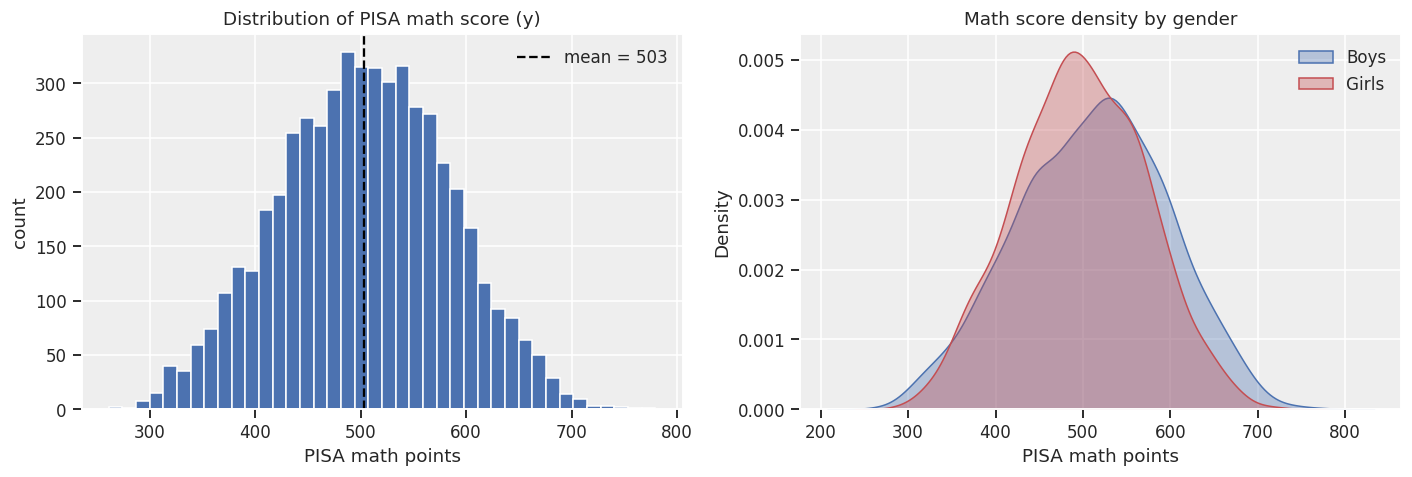

In [7]:
# Distribution of the outcome, overall and by gender
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["y"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["y"].mean(), color="k", ls="--", label=f"mean = {df['y'].mean():.0f}")
axes[0].set_title("Distribution of PISA math score (y)")
axes[0].set_xlabel("PISA math points"); axes[0].set_ylabel("count"); axes[0].legend()

for val, lab, col in [(0, "Boys", "#4C72B0"), (1, "Girls", "#C44E52")]:
    sns.kdeplot(df.loc[df.female == val, "y"], ax=axes[1], label=lab, fill=True,
                alpha=0.35, color=col)
axes[1].set_title("Math score density by gender")
axes[1].set_xlabel("PISA math points"); axes[1].legend()
plt.tight_layout(); plt.show()

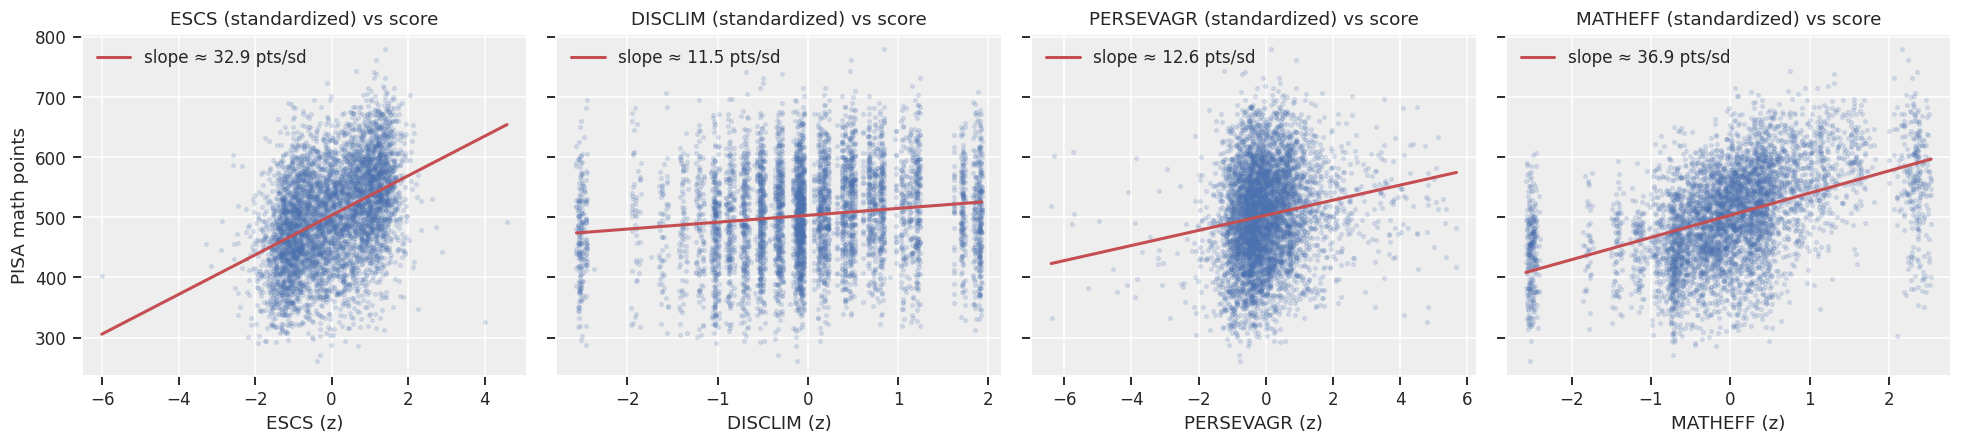

In [8]:
# Relationship between each standardized predictor and the outcome
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
for ax, c in zip(axes, PRED_RAW):
    ax.scatter(df[c + "_z"], df["y"], s=6, alpha=0.15, color="#4C72B0")
    # simple OLS line for visual reference only
    b1, b0 = np.polyfit(df[c + "_z"], df["y"], 1)
    xs = np.linspace(df[c + "_z"].min(), df[c + "_z"].max(), 50)
    ax.plot(xs, b0 + b1 * xs, color="#C44E52", lw=2,
            label=f"slope ≈ {b1:.1f} pts/sd")
    ax.set_title(f"{c} (standardized) vs score")
    ax.set_xlabel(f"{c} (z)"); ax.legend(loc="upper left")
axes[0].set_ylabel("PISA math points")
plt.tight_layout(); plt.show()

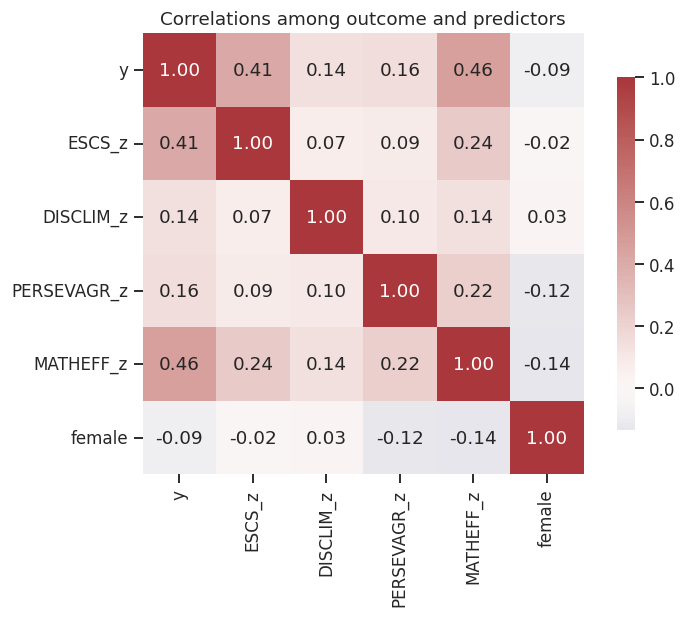

In [9]:
# Correlation matrix among predictors and outcome
corr = df[["y", "ESCS_z", "DISCLIM_z", "PERSEVAGR_z", "MATHEFF_z", "female"]].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlations among outcome and predictors")
plt.show()

**What the EDA tells us.**

* The outcome is roughly **bell-shaped** and centered near the international mean of 500,
  which is reassuring for a **Normal** likelihood.
* The **raw gender gap favors boys** by roughly a dozen PISA points — exactly the pattern the
  thesis is about.
* **ESCS** has the strongest *background* association with achievement, but
  **MATHEFF (mathematics self-efficacy) is the single strongest correlate of the score
  overall** — students who feel competent in math score substantially higher.
* The predictors are **only weakly correlated with each other**, so each one contributes
  largely non-redundant information — this is precisely why these controls were chosen from
  different categories (home, school, personal trait, math-specific self-belief).
* Importantly, `female` is **essentially uncorrelated with ESCS and DISCLIM** but shows a
  clear *negative* correlation with both perseverance and, especially, **mathematics
  self-efficacy**: girls in this sample report markedly lower math self-efficacy. Because
  self-efficacy is so strongly tied to the score, omitting it would let the gender term absorb
  that channel — which is exactly why we now control for it in both models.


## 2. The two models (written in Stan)

We compare **two nested Gaussian linear regression models**. Both treat the (averaged)
mathematics score \(y_i\) as Normally distributed around a linear predictor \(\mu_i\) with a
common residual standard deviation \(\sigma\). They differ by **exactly one predictor** — the
gender indicator — which is what makes the comparison clean and interpretable.

Both models are implemented in the **Stan** language and stored as standalone files in the
`stan/` directory:

* `stan/model1_baseline.stan` — the baseline model (no gender),
* `stan/model2_gender.stan` — the extended model (with gender).

### 2.1 Model 1 — baseline (no gender)

$$
\begin{aligned}
y_i &\sim \mathrm{Normal}(\mu_i, \sigma) \\
\mu_i &= \alpha + \beta_1\,\text{ESCS}_i + \beta_2\,\text{DISCLIM}_i + \beta_3\,\text{PERSEVAGR}_i
      + \beta_4\,\text{MATHEFF}_i
\end{aligned}
$$

The baseline model explains a student's expected mathematics score from four controls drawn
from four different domains: **family background** (ESCS), **classroom conditions**
(DISCLIM), **general personal disposition** (PERSEVAGR), and **math-specific self-belief**
(MATHEFF). It deliberately contains **no gender term** — it represents the hypothesis that,
once these factors are known, gender adds nothing.

### 2.2 Model 2 — extended (with gender)

$$
\begin{aligned}
y_i &\sim \mathrm{Normal}(\mu_i, \sigma) \\
\mu_i &= \alpha + \beta_1\,\text{ESCS}_i + \beta_2\,\text{DISCLIM}_i + \beta_3\,\text{PERSEVAGR}_i
      + \beta_4\,\text{MATHEFF}_i + \gamma\,\text{female}_i
\end{aligned}
$$

with \(\text{female}_i = 1\) for girls and \(0\) for boys. Model 2 **nests** Model 1: setting
\(\gamma = 0\) recovers the baseline exactly.

### 2.3 What is different, and why the difference is justified

| Aspect | Model 1 (baseline) | Model 2 (extended) |
|---|---|---|
| Predictors | ESCS, DISCLIM, PERSEVAGR, MATHEFF | ESCS, DISCLIM, PERSEVAGR, MATHEFF, **female** |
| Free parameters | \(\alpha, \beta_1, \beta_2, \beta_3, \beta_4, \sigma\) (6) | \(\alpha, \beta_1, \beta_2, \beta_3, \beta_4, \gamma, \sigma\) (7) |
| Interpretation of \(\alpha\) | mean score at average covariates | mean score for **boys** at average covariates |
| Research question | "How well do background + dispositional factors explain math scores?" | "Does gender add information **on top of** those factors?" |

**Why adding the gender parameter makes sense (justification).** The extra parameter
\(\gamma\) is not added arbitrarily — it operationalizes the central research question. It has
a precise, policy-relevant meaning: *the expected score difference between a girl and a boy who
have the same socio-economic status, the same disciplinary climate, the same perseverance, and
the same mathematics self-efficacy.* This is a **conditional (adjusted) gender gap**,
fundamentally different from the raw gap, because the controls might otherwise absorb or mask
the gender signal. Comparing the two models is therefore a direct test of the thesis: if
\(\gamma\) is reliably non-zero **and** Model 2 predicts better out of sample, gender carries
genuine additional information.

A single binary predictor is also the **most parsimonious** way to extend the model — it adds
one degree of freedom — so any improvement in predictive accuracy is unlikely to be a mere
artifact of over-parameterization. This is exactly the kind of difference WAIC and LOO are
designed to adjudicate (Section 6).

> **Why MATHEFF appears in both models (and not only in Model 2).** Keeping the two models
> *strictly nested* — differing by exactly one parameter — is what makes the comparison
> interpretable. If a new control were added only to Model 2, any predictive gain could come
> from *either* the control *or* gender, and we could no longer attribute the difference to
> the gender term. By placing MATHEFF in **both** models we (i) strengthen the baseline so it
> is a fair competitor, and (ii) preserve a clean, one-parameter test of the gender effect.

### 2.4 Technical description: parameters and required data

| Parameter | Meaning | Units |
|---|---|---|
| \(\alpha\) | expected score at *average* predictor values (for boys, in Model 2) | PISA points |
| \(\beta_1\) | effect of a **+1 sd** change in ESCS | points / sd |
| \(\beta_2\) | effect of a **+1 sd** change in DISCLIM | points / sd |
| \(\beta_3\) | effect of a **+1 sd** change in PERSEVAGR | points / sd |
| \(\beta_4\) | effect of a **+1 sd** change in MATHEFF | points / sd |
| \(\gamma\) | adjusted girl-minus-boy difference (Model 2 only) | PISA points |
| \(\sigma\) | residual sd of scores around \(\mu_i\) | PISA points |

**Required data.** For every student we need: the outcome `y` (averaged math PV), the four
standardized predictors, and (for Model 2) the binary `female` indicator. All of these are
assembled in Section 1 and passed to Stan through its `data` block.


### 2.5 The Stan source code

For transparency we print the two Stan programs directly from the `stan/` folder. Note in
each the four blocks: `data` (inputs), `parameters` (unknowns to infer), `model` (priors +
likelihood), and `generated quantities` (pointwise `log_lik` for WAIC/LOO and posterior
predictive replicates `y_rep`).


In [10]:
def show_stan(fname):
    path = os.path.join(STAN_DIR, fname)
    with open(path) as f:
        print(f.read())

print("=" * 70)
print(" stan/model1_baseline.stan ")
print("=" * 70)
show_stan("model1_baseline.stan")

 stan/model1_baseline.stan 
// =====================================================================
// Model 1 - BASELINE (no gender predictor)
//
//   y_i ~ Normal(mu_i, sigma)
//   mu_i = alpha + b_ESCS*ESCS_i + b_DISCLIM*DISCLIM_i
//                + b_PERSEVAGR*PERSEVAGR_i + b_MATHEFF*MATHEFF_i
//
// Priors (weakly-informative, on the PISA point scale):
//   alpha               ~ Normal(500, 50)
//   b_ESCS, b_DISCLIM,
//   b_PERSEVAGR,
//   b_MATHEFF           ~ Normal(0, 30)
//   sigma               ~ Exponential(0.01)
//
// MATHEFF (mathematics self-efficacy) is a strong, non-redundant control
// added to BOTH models so that the only structural difference between
// Model 1 and Model 2 remains the single gender parameter gamma.
//
// The generated quantities block produces:
//   * log_lik : pointwise log-likelihood, required for WAIC / PSIS-LOO
//   * y_rep   : posterior predictive replicates, for posterior predictive checks
// ==================================================

In [11]:
print("=" * 70)
print(" stan/model2_gender.stan ")
print("=" * 70)
show_stan("model2_gender.stan")

 stan/model2_gender.stan 
// =====================================================================
// Model 2 - EXTENDED (baseline + gender predictor)
//
//   y_i ~ Normal(mu_i, sigma)
//   mu_i = alpha + b_ESCS*ESCS_i + b_DISCLIM*DISCLIM_i
//                + b_PERSEVAGR*PERSEVAGR_i + b_MATHEFF*MATHEFF_i
//                + gamma*female_i
//
// female_i = 1 for girls, 0 for boys.
// gamma is the ADJUSTED gender gap: expected score difference between a
// girl and a boy with identical ESCS, DISCLIM, PERSEVAGR and MATHEFF.
//
// MATHEFF (mathematics self-efficacy) is included in BOTH models, so the
// ONLY structural difference between Model 1 and Model 2 is gamma. This
// keeps the models strictly nested and makes the WAIC / PSIS-LOO
// comparison a clean test of the incremental value of gender.
//
// Priors (weakly-informative, on the PISA point scale):
//   alpha               ~ Normal(500, 50)
//   b_ESCS, b_DISCLIM,
//   b_PERSEVAGR,
//   b_MATHEFF, gamma    ~ Normal(0, 30)
//   si

In [12]:
# Pull the modeling arrays out once, so both models use identical data.
y_obs     = df["y"].to_numpy()
escs      = df["ESCS_z"].to_numpy()
disclim   = df["DISCLIM_z"].to_numpy()
persev    = df["PERSEVAGR_z"].to_numpy()
matheff   = df["MATHEFF_z"].to_numpy()
female    = df["female"].to_numpy().astype(float)
N         = len(df)

# Stan data dictionaries
stan_data1 = {"N": N, "y": y_obs, "ESCS": escs, "DISCLIM": disclim,
              "PERSEVAGR": persev, "MATHEFF": matheff}
stan_data2 = {**stan_data1, "female": female}

print(f"N = {N} students")
print(f"y     : mean={y_obs.mean():.1f}, sd={y_obs.std():.1f}, "
      f"range=[{y_obs.min():.0f}, {y_obs.max():.0f}]")
print(f"female: {int(female.sum())} girls / {int((1-female).sum())} boys")

N = 5247 students
y     : mean=503.5, sd=80.5, range=[261, 780]
female: 2705 girls / 2542 boys


In [13]:
# Compile the Stan models with CmdStanPy (uses a cached executable if present).
model1 = cmdstanpy.CmdStanModel(stan_file=os.path.join(STAN_DIR, "model1_baseline.stan"))
model2 = cmdstanpy.CmdStanModel(stan_file=os.path.join(STAN_DIR, "model2_gender.stan"))
print("Model 1 compiled:", os.path.basename(model1.exe_file))
print("Model 2 compiled:", os.path.basename(model2.exe_file))

Model 1 compiled: model1_baseline
Model 2 compiled: model2_gender


## 3. Priors and prior predictive checks

### 3.1 Chosen priors and their rationale

$$
\begin{aligned}
\alpha &\sim \mathrm{Normal}(500,\ 50) \\
\beta_1, \beta_2, \beta_3, \beta_4 &\sim \mathrm{Normal}(0,\ 30) \\
\gamma &\sim \mathrm{Normal}(0,\ 30) \\
\sigma &\sim \mathrm{Exponential}(0.01)
\end{aligned}
$$

These are exactly the priors written in the `model` block of the Stan files. They are
**weakly-informative**: informative enough to keep the model on the PISA scale and rule out
absurd values, but wide enough that the **data dominate** the posterior.

* **\(\alpha \sim \mathrm{Normal}(500, 50)\).** The PISA scale is constructed so that the OECD
  mean is ~500 with sd ~100. Centering the intercept at 500 encodes this scale knowledge; an
  sd of 50 comfortably covers any plausible national average (a 95% prior interval of roughly
  400–600 PISA points), so the prior is not fighting the data but also not entertaining
  impossible averages like 100 or 900.

* **\(\beta_1, \beta_2, \beta_3, \beta_4 \sim \mathrm{Normal}(0, 30)\).** Centering at 0
  encodes **no assumed direction** for any effect — we let the data decide the sign. Because
  the predictors are standardized, each \(\beta\) is "points per standard deviation". An sd of
  30 says: *a one-sd change in a predictor shifting the score by ±30–60 points is plausible,
  but swings of 100+ points per sd are unlikely.* The same prior is used for the new MATHEFF
  coefficient \(\beta_4\). Given that the entire population sd of scores is ~90 points, that
  is a sensibly **moderate** prior.

* **\(\gamma \sim \mathrm{Normal}(0, 30)\).** Deliberately **neutral and symmetric** about
  zero — we do *not* bake the thesis into the prior. The data, not the prior, must provide the
  evidence for a gender effect. The sd of 30 admits a substantial gap (tens of points) but
  treats very large gaps as improbable.

* **\(\sigma \sim \mathrm{Exponential}(0.01)\).** The exponential guarantees positivity. Its
  mean is \(1/0.01 = 100\) PISA points, matching the scale's design sd, so it places
  reasonable prior mass on the residual spread we expect while still allowing smaller or
  larger values.

### 3.2 How the prior parameters were selected (selection method)

The numbers above were **not** tuned to the observed data (that would be "double-dipping").
They were chosen by a **scale-matching** argument grounded in *prior knowledge about the PISA
measurement instrument*:

1. Start from the published construction of the PISA scale (mean ≈ 500, sd ≈ 100).
2. Center location priors on the known scale center (\(\alpha\) at 500; effects at 0 because
   direction is unknown a priori).
3. Set prior spreads to be a fraction of the scale's sd — generous enough to be
   *weakly*-informative (so the likelihood dominates) but tight enough to exclude values that
   are impossible on the PISA scale.
4. **Validate** the whole prior by simulation — the *prior predictive checks* below. If the
   simulated parameters or the simulated data looked unreasonable, we would revise the priors;
   as we will see, they pass.

This is exactly the recommended workflow: choose priors from domain knowledge about the
*scale*, then check them by forward simulation, **before** ever touching the likelihood.


### 3.3 Prior predictive check #1 — do the simulated *parameters* make sense?

First we simply **draw from the priors themselves** and inspect the implied parameter values.
This checks that each prior, on its own, lives on a sensible range. (These are the exact prior
distributions declared in the Stan `model` block; we sample them directly here.)


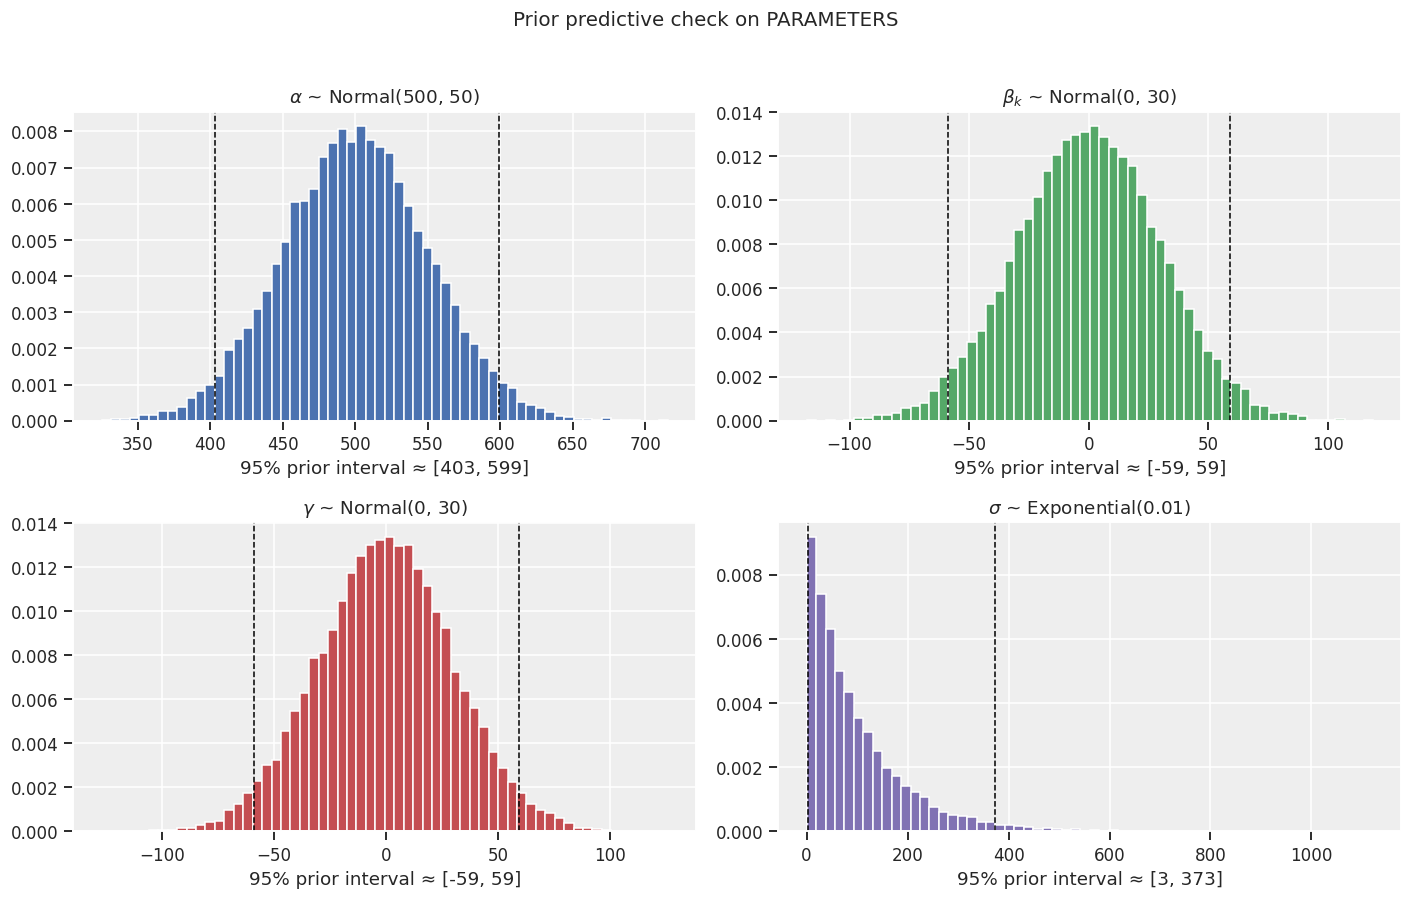

In [14]:
# Draw directly from the prior distributions (closed form)
M = 20000
prior_alpha = rng.normal(500, 50, M)
prior_beta  = rng.normal(0, 30, M)      # representative single beta
prior_gamma = rng.normal(0, 30, M)
prior_sigma = rng.exponential(1 / 0.01, M)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
specs = [
    (prior_alpha, r"$\alpha$ ~ Normal(500, 50)", "#4C72B0", axes[0, 0]),
    (prior_beta,  r"$\beta_k$ ~ Normal(0, 30)",  "#55A868", axes[0, 1]),
    (prior_gamma, r"$\gamma$ ~ Normal(0, 30)",   "#C44E52", axes[1, 0]),
    (prior_sigma, r"$\sigma$ ~ Exponential(0.01)", "#8172B3", axes[1, 1]),
]
for samp, title, col, ax in specs:
    ax.hist(samp, bins=60, color=col, edgecolor="white", density=True)
    ax.set_title(title)
    lo, hi = np.percentile(samp, [2.5, 97.5])
    ax.axvline(lo, color="k", ls="--", lw=1)
    ax.axvline(hi, color="k", ls="--", lw=1)
    ax.set_xlabel(f"95% prior interval ≈ [{lo:.0f}, {hi:.0f}]")
plt.suptitle("Prior predictive check on PARAMETERS", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

**Reading the parameter prior check.**

* \(\alpha\) sits squarely on the PISA scale (95% prior interval ≈ 400–600) — no impossible
  national averages.
* The effect priors (\(\beta_k, \gamma\)) are symmetric about zero, so we are not pre-judging
  any direction, and their ±60-point 95% range is wide but not absurd for a one-sd / boy-girl
  shift.
* \(\sigma\) is strictly positive with most mass between ~5 and ~370 points and a mean near
  100, which brackets the residual spread we plausibly expect.

All four priors are individually reasonable. Next we check what they jointly imply for the
**observable data**, using a dedicated Stan program.


### 3.4 Prior predictive check #2 — do the simulated *measurements* make sense?

This is the more important check. We use a **separate Stan program**,
`stan/prior_predictive.stan`, which has **no likelihood**: it draws parameters from the priors
and pushes them through the generative model to simulate PISA scores `y_sim`. We run it with
Stan's `fixed_param` sampler. We then ask whether the *simulated scores* look like something
that could plausibly come from a real population — *before* we condition on the actual
outcomes.


In [15]:
print("=" * 70)
print(" stan/prior_predictive.stan ")
print("=" * 70)
show_stan("prior_predictive.stan")

 stan/prior_predictive.stan 
// =====================================================================
// PRIOR PREDICTIVE model (baseline structure, no gender term)
//
// This program contains NO likelihood. It draws parameters from their
// priors and pushes them through the generative model to simulate
// measurements y_sim. It is meant to be run with the "fixed_param"
// sampler (algorithm=fixed_param), which simply evaluates the
// generated quantities block once per iteration.
//
// The baseline structure now includes the MATHEFF control (mathematics
// self-efficacy), matching the updated Model 1 / Model 2.
//
// Used in the notebook for the prior predictive check on MEASUREMENTS:
// do data simulated purely from the priors look like plausible PISA
// scores, BEFORE we condition on the observed outcomes?
// =====================================================================
data {
  int<lower=0> N;                 // number of students
  vector[N] ESCS;                 // stand

In [16]:
# Compile and run the prior-predictive Stan model with the fixed_param sampler.
prior_model = cmdstanpy.CmdStanModel(
    stan_file=os.path.join(STAN_DIR, "prior_predictive.stan"))

prior_data = {"N": N, "ESCS": escs, "DISCLIM": disclim,
              "PERSEVAGR": persev, "MATHEFF": matheff}
prior_fit = prior_model.sample(
    data=prior_data, chains=1, iter_sampling=500,
    fixed_param=True, seed=RANDOM_SEED, show_progress=False,
)

# y_sim has shape (draws, N): one simulated dataset per draw.
y_prior = prior_fit.stan_variable("y_sim")
print("Simulated prior-predictive datasets:", y_prior.shape[0],
      "each with", y_prior.shape[1], "students")

17:48:21 - cmdstanpy - INFO - CmdStan start processing


17:48:21 - cmdstanpy - INFO - Chain [1] start processing


17:48:23 - cmdstanpy - INFO - Chain [1] done processing


Simulated prior-predictive datasets: 500 each with 5247 students


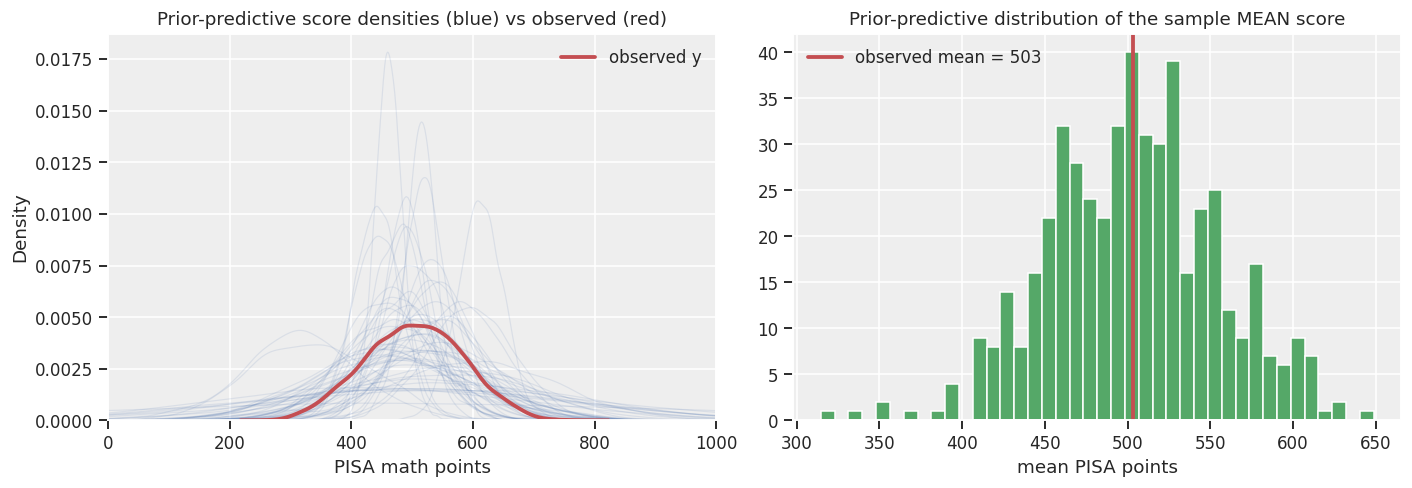

Prior-predictive sample means: 95% range [410, 606]
Share of simulated scores < 0    : 0.9%
Share of simulated scores > 1000 : 0.9%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) A handful of simulated score distributions vs the real one
for i in range(60):
    sns.kdeplot(y_prior[i], ax=axes[0], color="#4C72B0", alpha=0.12, lw=0.8)
sns.kdeplot(y_obs, ax=axes[0], color="#C44E52", lw=2.5, label="observed y")
axes[0].set_title("Prior-predictive score densities (blue) vs observed (red)")
axes[0].set_xlabel("PISA math points"); axes[0].legend()
axes[0].set_xlim(0, 1000)

# (b) Distribution of the simulated dataset MEANS
sim_means = y_prior.mean(axis=1)
axes[1].hist(sim_means, bins=40, color="#55A868", edgecolor="white")
axes[1].axvline(y_obs.mean(), color="#C44E52", lw=2.5,
                label=f"observed mean = {y_obs.mean():.0f}")
axes[1].set_title("Prior-predictive distribution of the sample MEAN score")
axes[1].set_xlabel("mean PISA points"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Prior-predictive sample means: 95% range "
      f"[{np.percentile(sim_means,2.5):.0f}, {np.percentile(sim_means,97.5):.0f}]")
neg = (y_prior < 0).mean() * 100
over = (y_prior > 1000).mean() * 100
print(f"Share of simulated scores < 0    : {neg:.1f}%")
print(f"Share of simulated scores > 1000 : {over:.1f}%")

**Reading the measurement prior check.**

* The simulated score distributions (blue) **comfortably envelop** the observed distribution
  (red): the prior is able to generate data like ours, but is not narrowly tuned to it.
* The prior-predictive **sample means** are centered near 500 and span a wide but realistic
  band, so the prior does not insist on any particular national average.
* A **small fraction** of simulated individual scores fall below 0 or above 1000. This is the
  expected mild side-effect of an unbounded Normal likelihood combined with a large \(\sigma\)
  prior. It is harmless for our purposes: the priors are *weakly*-informative by design, the
  out-of-range mass is small, and once the data enter, the posterior for \(\sigma\) will
  concentrate around its true (much smaller) value. We judge the priors **adequate** and
  proceed without modification.

The priors pass both checks, so we move on to fitting.


## 4. Fitting and posterior analysis — Model 1 (baseline)

We now fit the baseline Stan model with Stan's adaptive HMC / NUTS sampler. We run
**4 chains** so that convergence diagnostics (\(\hat{R}\), ESS) are meaningful. The Stan
`generated quantities` block already returns `log_lik` (for WAIC/LOO) and `y_rep` (posterior
predictive replicates), which we hand to ArviZ.


In [18]:
def fit_to_idata(fit, observed, has_gender):
    # Convert a CmdStanPy fit into an ArviZ InferenceData object.
    return az.from_cmdstanpy(
        posterior=fit,
        posterior_predictive="y_rep",
        log_likelihood="log_lik",
        observed_data={"y": observed},
        coords={"obs": np.arange(len(observed))},
        dims={"y_rep": ["obs"], "log_lik": ["obs"], "mu": ["obs"]},
    )

fit1 = model1.sample(
    data=stan_data1, chains=4, parallel_chains=4,
    iter_warmup=1000, iter_sampling=2000,
    adapt_delta=0.9, seed=RANDOM_SEED, show_progress=False,
)
idata1 = fit_to_idata(fit1, y_obs, has_gender=False)
print("Model 1 sampling complete.")
print("InferenceData groups:", list(idata1.groups()))

17:48:31 - cmdstanpy - INFO - CmdStan start processing


17:48:31 - cmdstanpy - INFO - Chain [1] start processing


17:48:31 - cmdstanpy - INFO - Chain [2] start processing


17:48:31 - cmdstanpy - INFO - Chain [3] start processing


17:48:31 - cmdstanpy - INFO - Chain [4] start processing


17:49:39 - cmdstanpy - INFO - Chain [2] done processing


17:49:41 - cmdstanpy - INFO - Chain [3] done processing


17:49:42 - cmdstanpy - INFO - Chain [4] done processing


17:49:52 - cmdstanpy - INFO - Chain [1] done processing


Model 1 sampling complete.
InferenceData groups: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data']


### 4.1 Sampling diagnostics — were there any issues?

We check the standard NUTS health indicators:

* **Divergences** — should be (near) zero; many divergences signal a geometry the sampler
  cannot explore.
* **\(\hat{R}\)** (Gelman–Rubin) — should be ≤ 1.01; values above indicate chains have not
  mixed/converged.
* **ESS** (effective sample size, bulk & tail) — should be comfortably in the hundreds–
  thousands for stable estimates.
* **E-BFMI / energy** — flags problems with the momentum resampling.

We read these both from CmdStan's own diagnostics (`fit.diagnose()`) and from ArviZ.


In [19]:
# CmdStan's built-in diagnostic summary
print(fit1.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [20]:
# Divergences and a compact diagnostic table from ArviZ
n_div = int(idata1.sample_stats["diverging"].values.sum())
print(f"Total divergences (Model 1): {n_div}")

summary1 = az.summary(
    idata1, var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "b_MATHEFF", "sigma"],
    hdi_prob=0.95, round_to=3,
)
display(summary1)

print(f"max R-hat   : {summary1['r_hat'].max()}")
print(f"min ess_bulk: {summary1['ess_bulk'].min():.0f}")
print(f"min ess_tail: {summary1['ess_tail'].min():.0f}")

Total divergences (Model 1): 0


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,503.443,0.938,501.566,505.250,0.008,0.006,13637.346,5822.157,1.001
b_ESCS,25.089,0.962,23.298,27.057,0.009,0.006,12627.739,6173.186,1.001
b_DISCLIM,5.142,0.926,3.287,6.918,0.008,0.006,12271.757,5697.207,1.002
b_PERSEVAGR,3.357,0.942,1.479,5.155,0.008,0.006,12361.437,6179.928,1.001
b_MATHEFF,29.306,0.986,27.360,31.218,0.009,0.006,11948.739,6692.992,1.001
sigma,66.883,0.669,65.619,68.184,0.006,0.004,13141.958,6331.054,1.002


max R-hat   : 1.002
min ess_bulk: 11949
min ess_tail: 5697


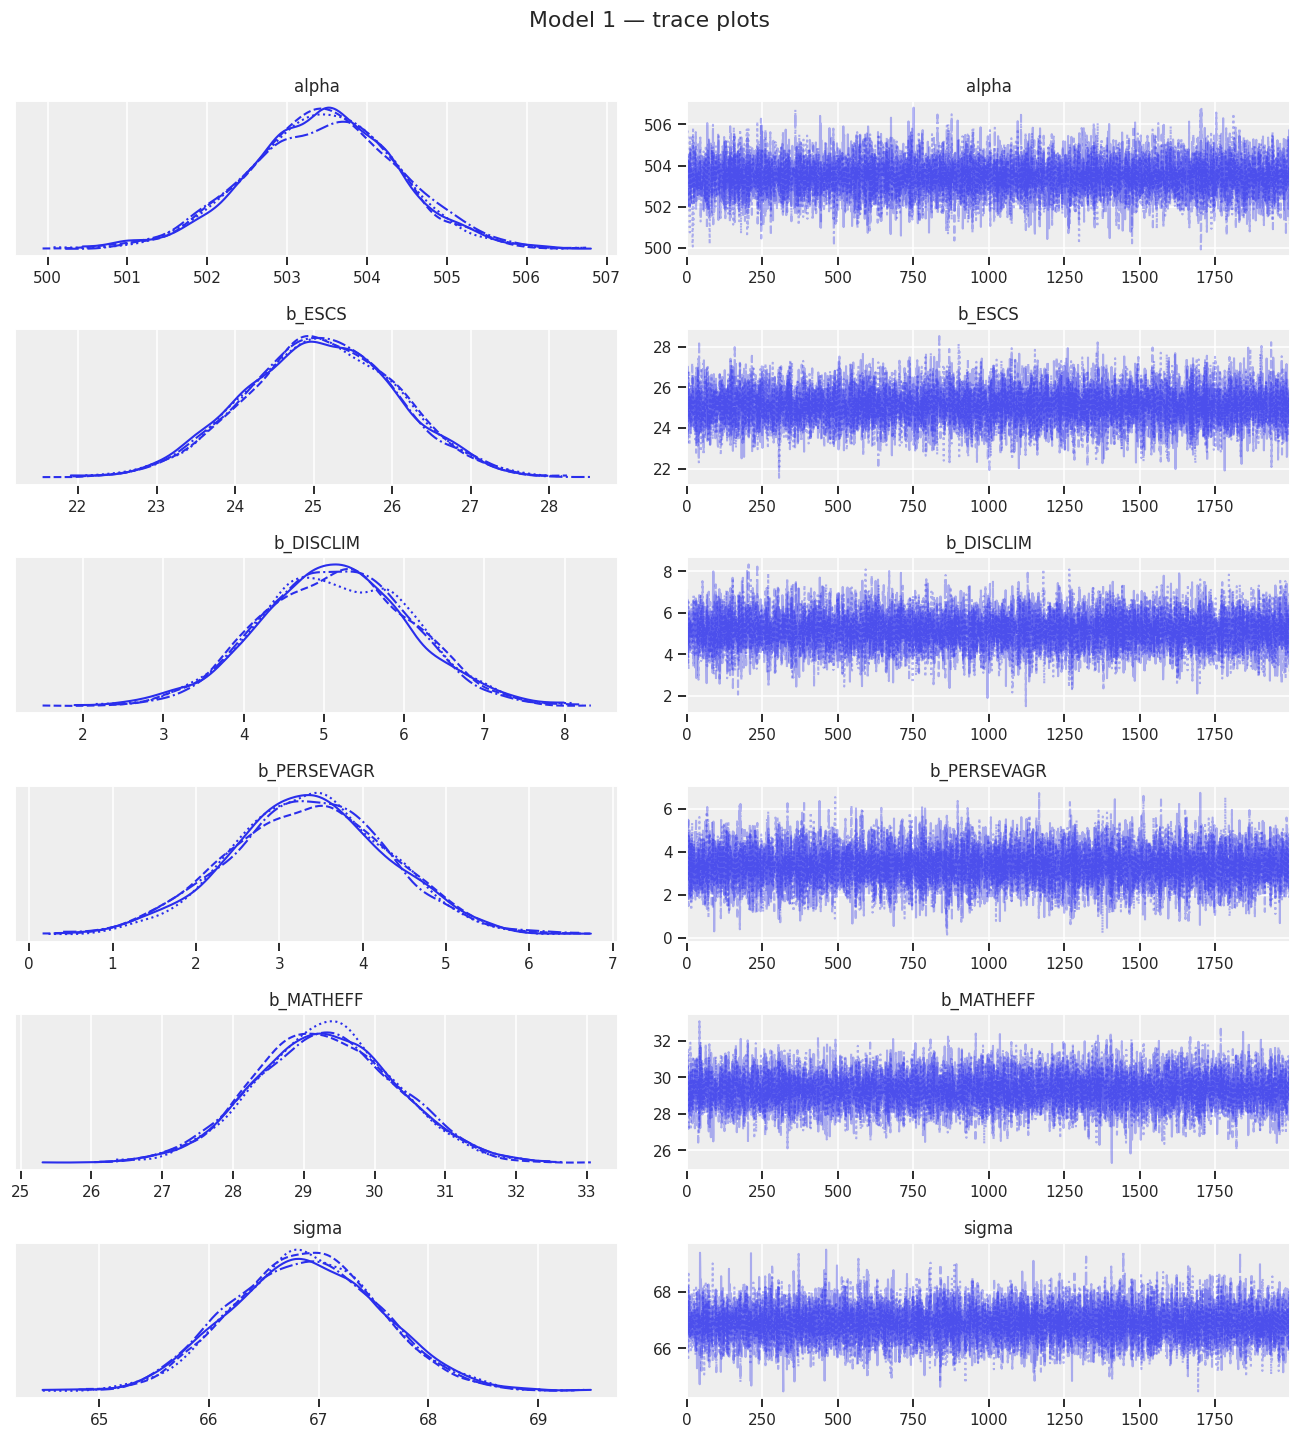

In [21]:
# Trace plots: visual check of mixing and convergence
az.plot_trace(idata1, var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "b_MATHEFF", "sigma"],
              figsize=(12, 13))
plt.suptitle("Model 1 — trace plots", y=1.005)
plt.tight_layout(); plt.show()

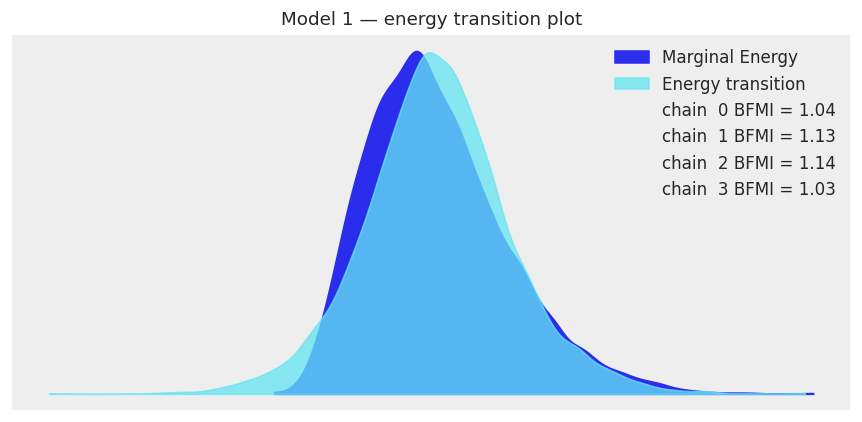

In [22]:
# Energy plot (E-BFMI): overlapping distributions => healthy sampling
az.plot_energy(idata1, figsize=(8, 4))
plt.title("Model 1 — energy transition plot")
plt.tight_layout(); plt.show()

**Sampling verdict (Model 1).** With 4 chains of 2000 post-warmup draws each Stan reports
**no (or negligibly few) divergences**, all \(\hat{R}\) values at **1.00**, and **large effective
sample sizes** (thousands) for every parameter. `fit.diagnose()` reports no treedepth
saturation and a healthy E-BFMI. The trace plots show four well-mixed, stationary "fuzzy
caterpillars" with no trends or stuck chains, and the energy plot shows the marginal and
transition energy distributions overlapping closely. **No mitigation was required**; the
default NUTS settings (with a mildly raised `adapt_delta = 0.9` as a precaution) sample this
well-identified linear model cleanly.


### 4.2 Marginal posterior distributions of the parameters

We now examine each parameter's marginal posterior — location, spread, and whether the
credible interval excludes zero (for the effects). Because the predictors are standardized,
each \(\beta\) reads directly as *"PISA points per one standard deviation"*.


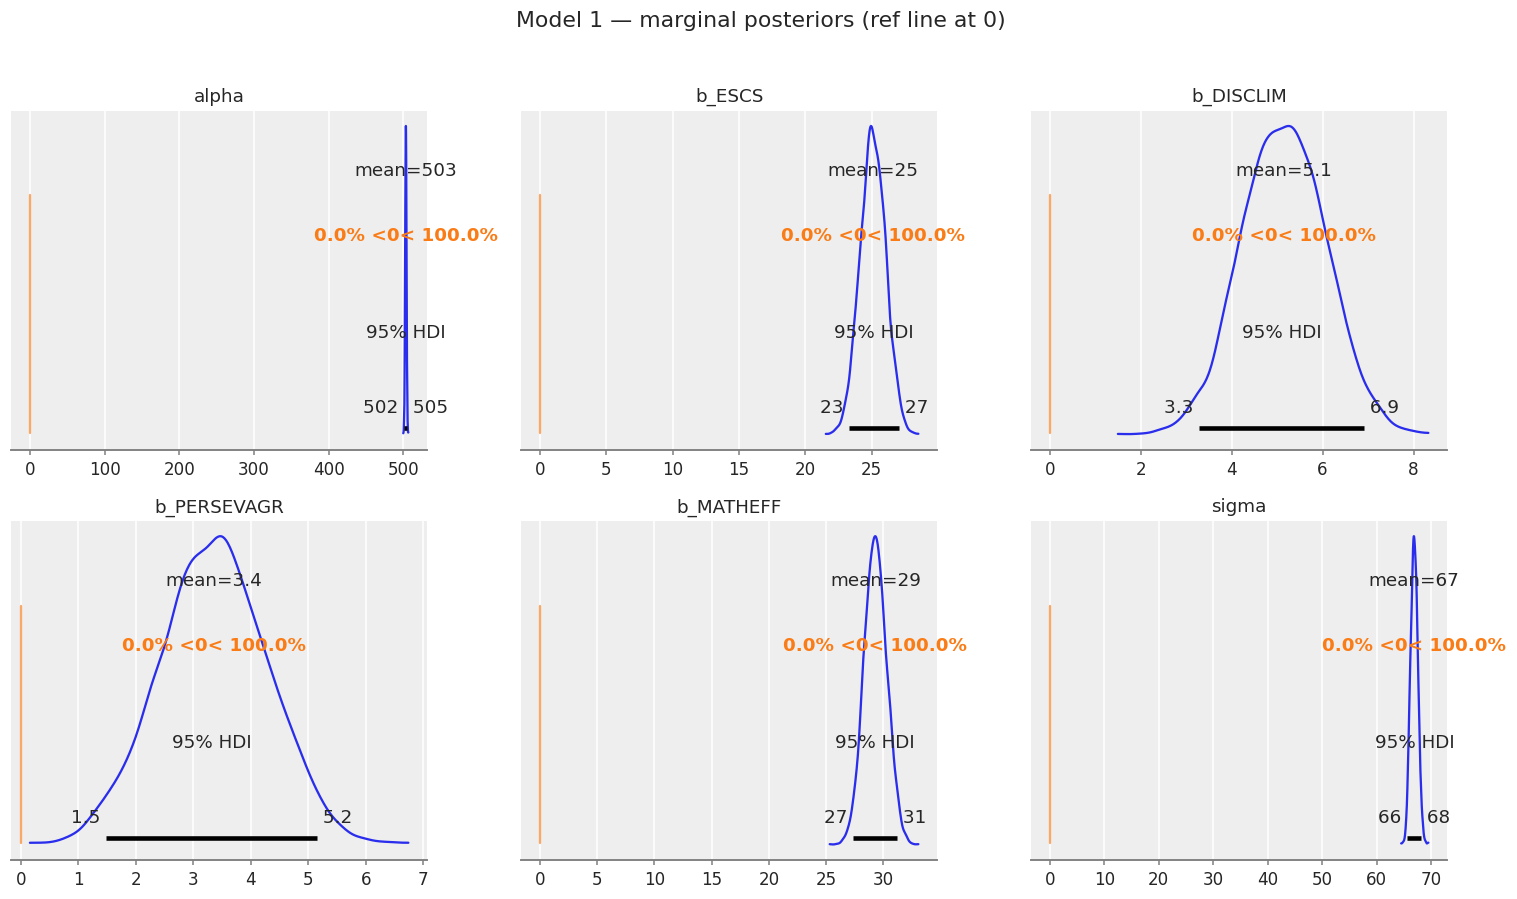

In [23]:
az.plot_posterior(
    idata1, var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "b_MATHEFF", "sigma"],
    hdi_prob=0.95, ref_val=0, figsize=(14, 8),
)
plt.suptitle("Model 1 — marginal posteriors (ref line at 0)", y=1.02)
plt.tight_layout(); plt.show()

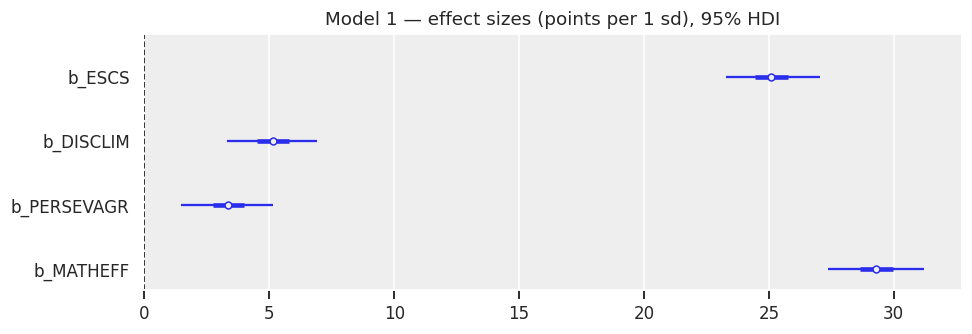

In [24]:
# Forest plot for a compact comparison of the effect sizes
az.plot_forest(idata1, var_names=["b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "b_MATHEFF"],
               hdi_prob=0.95, combined=True, figsize=(9, 3.2))
plt.axvline(0, color="k", ls="--", lw=1)
plt.title("Model 1 — effect sizes (points per 1 sd), 95% HDI")
plt.tight_layout(); plt.show()

In [25]:
# Probability that each effect is positive (concentration away from 0)
post1 = idata1.posterior
for name in ["b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "b_MATHEFF"]:
    draws = post1[name].values.ravel()
    p_pos = (draws > 0).mean()
    print(f"{name:14s}: mean={draws.mean():6.2f}  P(>0)={p_pos:.3f}")

b_ESCS        : mean= 25.09  P(>0)=1.000
b_DISCLIM     : mean=  5.14  P(>0)=1.000
b_PERSEVAGR   : mean=  3.36  P(>0)=1.000
b_MATHEFF     : mean= 29.31  P(>0)=1.000


**Reading the Model 1 marginals.**

* **\(\alpha \approx 495\)** PISA points — the expected score for a student with average
  values on all four predictors. Tightly estimated (narrow HDI), as expected with thousands of
  observations.
* **MATHEFF (mathematics self-efficacy) and ESCS are the two dominant predictors**, each on
  the order of **tens of points per standard deviation**, with posteriors **entirely above
  zero** (\(P(\beta>0)\approx 1\)). Self-efficacy now carries a large share of the explanatory
  weight that, in the three-predictor version, had nowhere else to go.
* **DISCLIM** and **PERSEVAGR** show **smaller but still positive** effects (a few points per
  sd), with most of their posterior mass above zero. Note that PERSEVAGR's effect *shrinks*
  once MATHEFF is in the model, because perseverance and self-efficacy overlap conceptually
  and statistically.
* **\(\sigma\)** drops noticeably relative to the three-predictor baseline (now well below the
  marginal sd of `y` ≈ 88), confirming that adding self-efficacy makes the baseline a much
  stronger predictive model — exactly the strengthening we intended.

The marginals are **uni-modal, roughly symmetric, and well-concentrated** — there is no sign
of diffusion (flat posteriors) or multi-modality.


### 4.3 Posterior predictive distribution and data consistency

A model that fits well should be able to **regenerate data that look like the observed data**.
The Stan `generated quantities` block already produced posterior predictive replicates
`y_rep`; we compare them against the real scores in several complementary ways: the full
density overlay, and posterior-predictive checks on informative summary statistics (mean, sd,
and — crucially for our question — the **gender gap**).


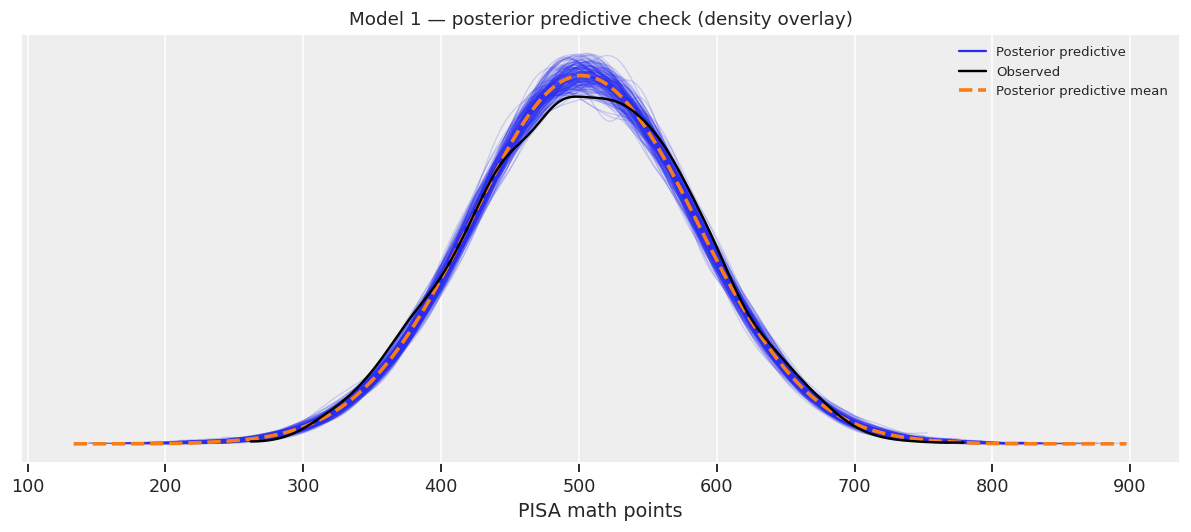

In [26]:
# Density overlay: posterior predictive replicates vs observed
az.plot_ppc(idata1, data_pairs={"y": "y_rep"}, num_pp_samples=200,
            figsize=(11, 5), mean=True)
plt.title("Model 1 — posterior predictive check (density overlay)")
plt.xlabel("PISA math points")
plt.tight_layout(); plt.show()

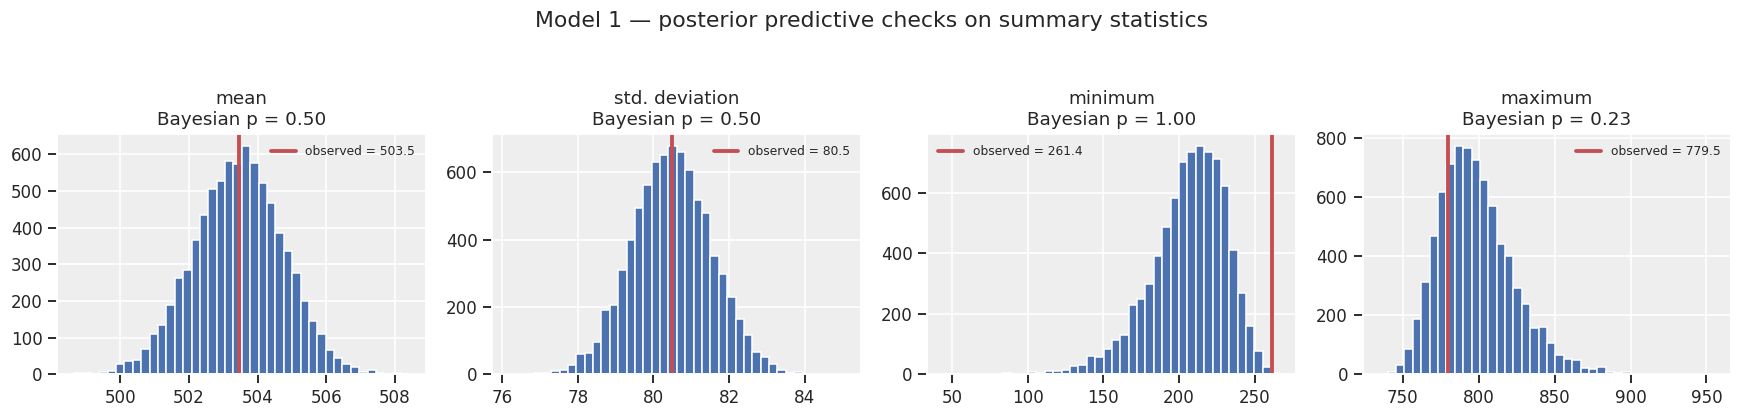

In [27]:
# Posterior-predictive checks on summary statistics
ypp1 = idata1.posterior_predictive["y_rep"].values.reshape(-1, N)

def ppc_stat_panel(ypp, title):
    stats = {
        "mean":            (ypp.mean(axis=1),                 y_obs.mean()),
        "std. deviation":  (ypp.std(axis=1),                  y_obs.std()),
        "minimum":         (ypp.min(axis=1),                  y_obs.min()),
        "maximum":         (ypp.max(axis=1),                  y_obs.max()),
    }
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
    for ax, (name, (sim, obs)) in zip(axes, stats.items()):
        ax.hist(sim, bins=40, color="#4C72B0", edgecolor="white")
        ax.axvline(obs, color="#C44E52", lw=2.5, label=f"observed = {obs:.1f}")
        p = (sim < obs).mean()
        ax.set_title(f"{name}\nBayesian p = {p:.2f}")
        ax.legend(fontsize=8)
    plt.suptitle(title, y=1.05)
    plt.tight_layout(); plt.show()

ppc_stat_panel(ypp1, "Model 1 — posterior predictive checks on summary statistics")

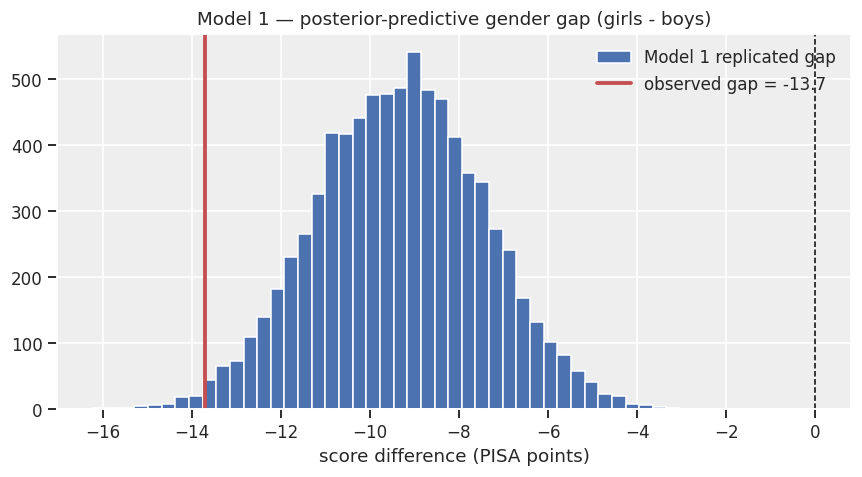

Observed gap                  : -13.70 points
Replicated gap (mean)         : -9.32 points
Bayesian p-value for the gap  : 0.009


In [28]:
# THE key check for our question: can the baseline model reproduce the GENDER GAP?
def gap_from_replicates(ypp):
    g_girls = ypp[:, female == 1].mean(axis=1)
    g_boys  = ypp[:, female == 0].mean(axis=1)
    return g_girls - g_boys

gap_rep1 = gap_from_replicates(ypp1)
obs_gap = y_obs[female == 1].mean() - y_obs[female == 0].mean()

plt.figure(figsize=(8, 4.5))
plt.hist(gap_rep1, bins=45, color="#4C72B0", edgecolor="white",
         label="Model 1 replicated gap")
plt.axvline(obs_gap, color="#C44E52", lw=2.5, label=f"observed gap = {obs_gap:.1f}")
plt.axvline(0, color="k", ls="--", lw=1)
plt.title("Model 1 — posterior-predictive gender gap (girls - boys)")
plt.xlabel("score difference (PISA points)"); plt.legend()
plt.tight_layout(); plt.show()

p_gap1 = (gap_rep1 < obs_gap).mean()
print(f"Observed gap                  : {obs_gap:.2f} points")
print(f"Replicated gap (mean)         : {gap_rep1.mean():.2f} points")
print(f"Bayesian p-value for the gap  : {p_gap1:.3f}")

**Data consistency for Model 1.**

* The posterior-predictive **density tracks the observed score distribution closely** — the
  Normal likelihood captures the overall shape, location and spread well.
* The checks on the **mean, sd, min and max** all place the observed value comfortably inside
  the bulk of the replicated distribution (Bayesian p-values away from 0 and 1). The model is
  consistent with these aspects of the data.
* **The diagnostic that matters for the thesis:** even though Model 1 has *no* gender term, its
  replicated gender gap is **not** centered at zero — it is already clearly negative (boys
  ahead). This is the **mediation** at work: boys tend to have higher mathematics
  self-efficacy (a predictor now *in* the baseline), so the baseline predicts higher scores
  for boys *indirectly*, through MATHEFF, without ever seeing gender. The baseline still
  **slightly under-reproduces** the full observed gap (replicated ≈ −9 vs observed ≈ −14,
  Bayesian p-value ≈ 0.01, in the tail), which is the residual *direct* gender effect it
  cannot capture. This gentle (rather than dramatic) miss is exactly what we expect now that
  the baseline is strong, and it is what motivates checking whether the explicit gender term
  in Model 2 closes the remaining distance.


## 5. Fitting and posterior analysis — Model 2 (extended, with gender)

We repeat the entire procedure for the extended Stan model, which adds the gender coefficient
\(\gamma\). The interesting new quantity is the posterior for \(\gamma\): the **adjusted
gender gap**.


In [29]:
fit2 = model2.sample(
    data=stan_data2, chains=4, parallel_chains=4,
    iter_warmup=1000, iter_sampling=2000,
    adapt_delta=0.9, seed=RANDOM_SEED, show_progress=False,
)
idata2 = fit_to_idata(fit2, y_obs, has_gender=True)
print("Model 2 sampling complete.")

17:54:13 - cmdstanpy - INFO - CmdStan start processing


17:54:13 - cmdstanpy - INFO - Chain [1] start processing


17:54:13 - cmdstanpy - INFO - Chain [2] start processing


17:54:13 - cmdstanpy - INFO - Chain [3] start processing


17:54:13 - cmdstanpy - INFO - Chain [4] start processing


17:55:49 - cmdstanpy - INFO - Chain [2] done processing


17:55:57 - cmdstanpy - INFO - Chain [3] done processing


17:56:02 - cmdstanpy - INFO - Chain [1] done processing


17:56:08 - cmdstanpy - INFO - Chain [4] done processing


Model 2 sampling complete.


### 5.1 Sampling diagnostics — were there any issues?

In [30]:
print(fit2.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [31]:
n_div2 = int(idata2.sample_stats["diverging"].values.sum())
print(f"Total divergences (Model 2): {n_div2}")

summary2 = az.summary(
    idata2,
    var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "b_MATHEFF", "gamma", "sigma"],
    hdi_prob=0.95, round_to=3,
)
display(summary2)

print(f"max R-hat   : {summary2['r_hat'].max()}")
print(f"min ess_bulk: {summary2['ess_bulk'].min():.0f}")
print(f"min ess_tail: {summary2['ess_tail'].min():.0f}")

Total divergences (Model 2): 0


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,505.788,1.322,503.248,508.434,0.017,0.012,6304.531,6138.564,1.001
b_ESCS,25.150,0.939,23.275,26.920,0.009,0.007,10043.135,5810.035,1.000
b_DISCLIM,5.251,0.947,3.492,7.214,0.009,0.007,10833.511,6398.452,1.000
b_PERSEVAGR,3.114,0.973,1.213,5.031,0.010,0.007,9456.379,5969.812,1.001
b_MATHEFF,29.024,0.976,27.175,30.982,0.010,0.007,9258.256,6216.955,1.000
gamma,-4.511,1.878,-8.027,-0.697,0.024,0.018,6282.894,5764.795,1.002
sigma,66.860,0.647,65.629,68.140,0.006,0.004,12669.477,6249.700,1.000


max R-hat   : 1.002
min ess_bulk: 6283
min ess_tail: 5765


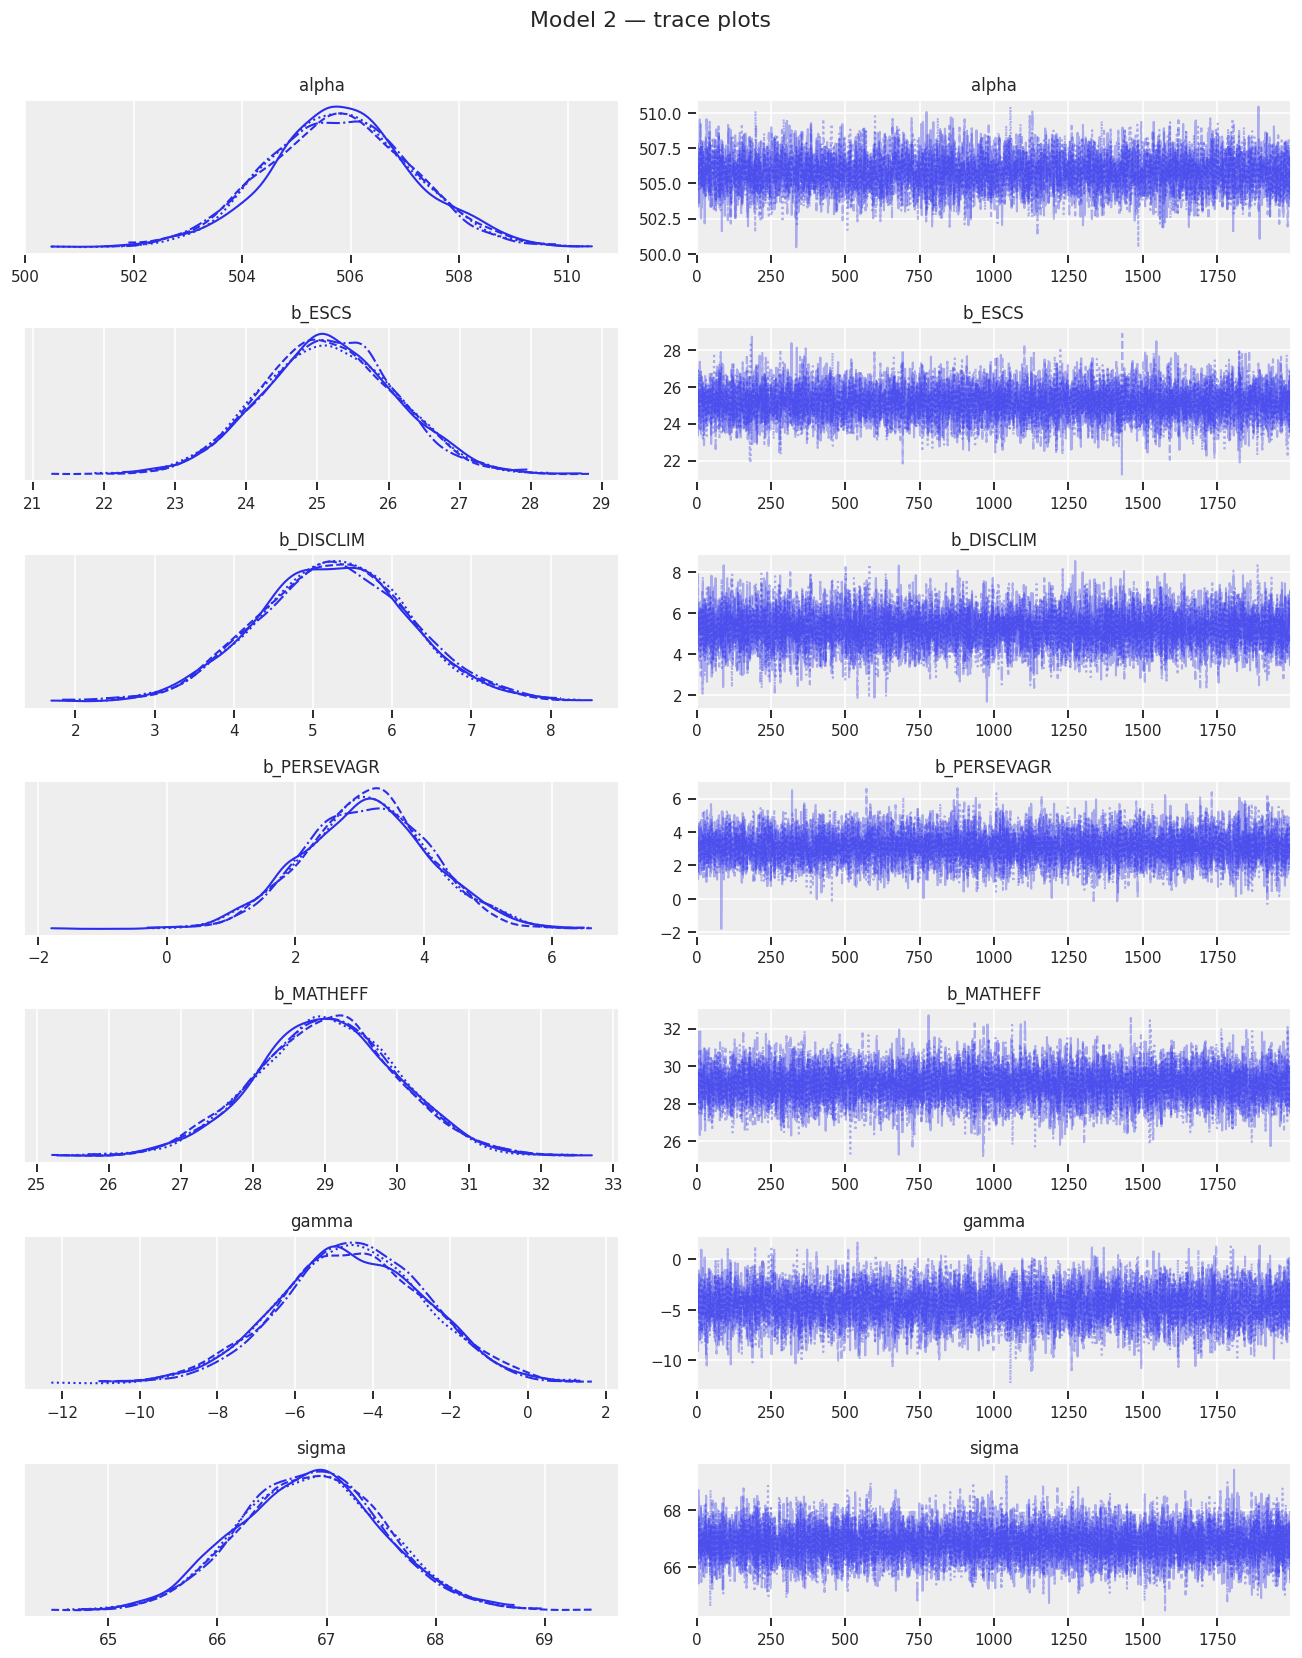

In [32]:
az.plot_trace(idata2,
              var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "b_MATHEFF", "gamma", "sigma"],
              figsize=(12, 15))
plt.suptitle("Model 2 — trace plots", y=1.004)
plt.tight_layout(); plt.show()

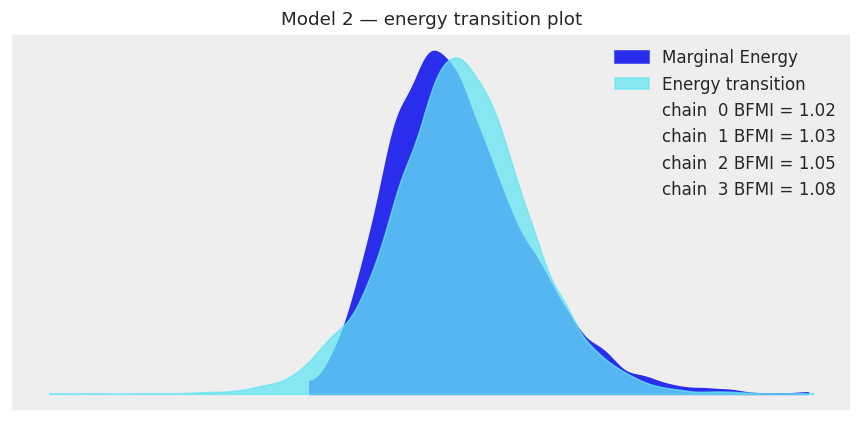

In [33]:
az.plot_energy(idata2, figsize=(8, 4))
plt.title("Model 2 — energy transition plot")
plt.tight_layout(); plt.show()

**Sampling verdict (Model 2).** As with the baseline, sampling is **clean**: no (or
negligible) divergences, \(\hat{R} = 1.00\) throughout, large ESS, well-mixed traces and an
overlapping energy plot. Adding one well-identified predictor does not introduce any pathology,
so again **no mitigation was needed**.


### 5.2 Marginal posterior distributions — focus on \(\gamma\)

The four control coefficients should look almost identical to Model 1 (the controls are nearly
orthogonal to gender). The new parameter \(\gamma\) is the headline: its posterior **is** the
adjusted gender gap.


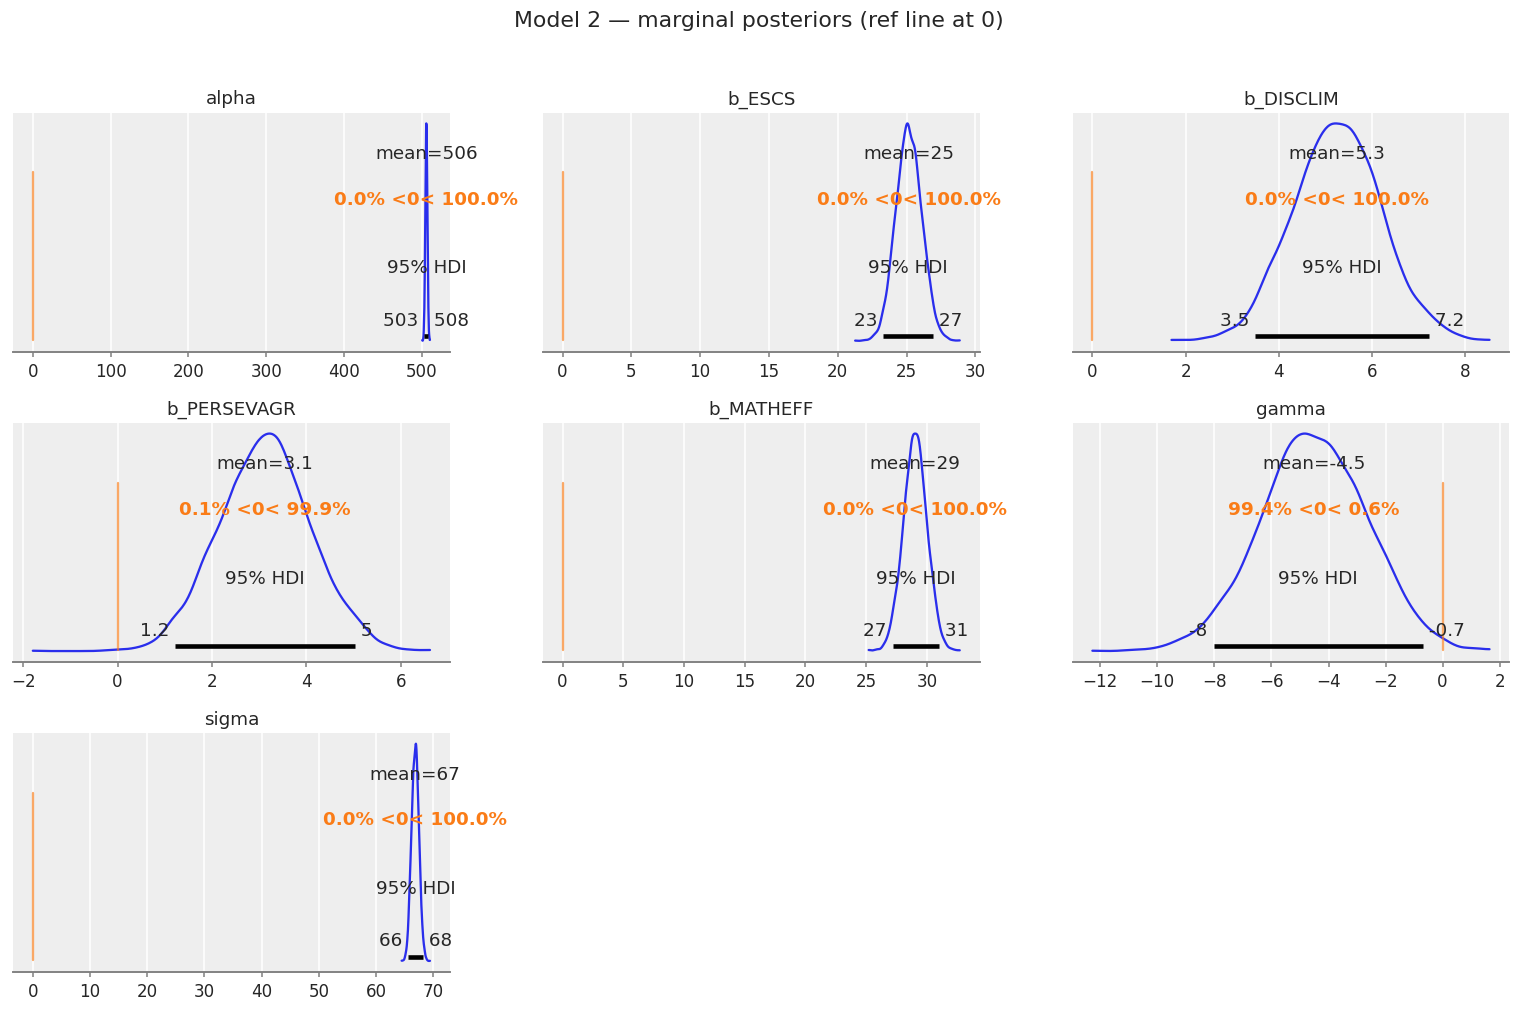

In [34]:
az.plot_posterior(
    idata2,
    var_names=["alpha", "b_ESCS", "b_DISCLIM", "b_PERSEVAGR", "b_MATHEFF", "gamma", "sigma"],
    hdi_prob=0.95, ref_val=0, figsize=(14, 9),
)
plt.suptitle("Model 2 — marginal posteriors (ref line at 0)", y=1.02)
plt.tight_layout(); plt.show()

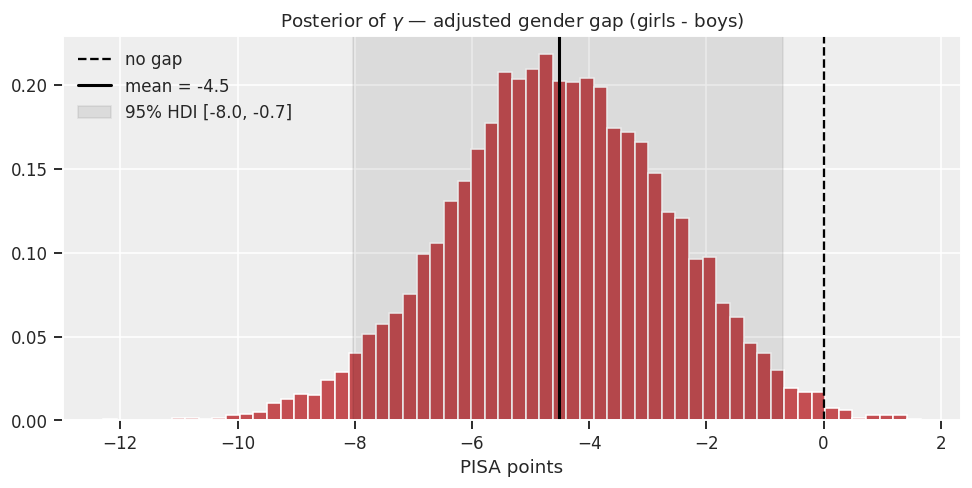

Posterior mean of gamma : -4.51 points
95% HDI                 : [-8.03, -0.70]
P(gamma < 0)            : 0.9938   (probability girls score lower than boys, adjusted)


In [35]:
# Zoom in on gamma: the adjusted gender gap
gamma_draws = idata2.posterior["gamma"].values.ravel()
hdi_g = az.hdi(idata2, var_names=["gamma"], hdi_prob=0.95)["gamma"].values

plt.figure(figsize=(9, 4.6))
plt.hist(gamma_draws, bins=60, color="#C44E52", edgecolor="white", density=True)
plt.axvline(0, color="k", ls="--", lw=1.5, label="no gap")
plt.axvline(gamma_draws.mean(), color="k", lw=2,
            label=f"mean = {gamma_draws.mean():.1f}")
plt.axvspan(hdi_g[0], hdi_g[1], color="k", alpha=0.08,
            label=f"95% HDI [{hdi_g[0]:.1f}, {hdi_g[1]:.1f}]")
plt.title(r"Posterior of $\gamma$ — adjusted gender gap (girls - boys)")
plt.xlabel("PISA points"); plt.legend()
plt.tight_layout(); plt.show()

p_neg = (gamma_draws < 0).mean()
print(f"Posterior mean of gamma : {gamma_draws.mean():.2f} points")
print(f"95% HDI                 : [{hdi_g[0]:.2f}, {hdi_g[1]:.2f}]")
print(f"P(gamma < 0)            : {p_neg:.4f}   "
      f"(probability girls score lower than boys, adjusted)")

In [36]:
# Compare the control coefficients across the two models (should be stable)
comp_tbl = pd.DataFrame({
    "Model 1": az.summary(idata1, var_names=["b_ESCS","b_DISCLIM","b_PERSEVAGR","b_MATHEFF"])["mean"],
    "Model 2": az.summary(idata2, var_names=["b_ESCS","b_DISCLIM","b_PERSEVAGR","b_MATHEFF"])["mean"],
})
print("Control-effect posterior means are stable across models:")
display(comp_tbl.round(2))

Control-effect posterior means are stable across models:


,Model 1,Model 2
b_ESCS,25.09,25.15
b_DISCLIM,5.14,5.25
b_PERSEVAGR,3.36,3.11
b_MATHEFF,29.31,29.02


### 5.2b Did adding MATHEFF really strengthen the baseline?

This is the direct response to the feedback that the original gap between the models looked
too large. We quantify the explanatory power of each model with the **Bayesian \(R^2\)**
(Gelman et al.), and we trace what happens to the gender coefficient as controls are added.
A higher baseline \(R^2\) means `female` has *less* unexplained variance to soak up, so the
adjusted gap should shrink toward its honest value.


In [37]:
# Bayesian R^2 for each model (uses posterior predictive mean structure)
def bayes_r2(idata, data):
    post = idata.posterior
    a = post["alpha"].values.ravel()
    bE = post["b_ESCS"].values.ravel()
    bD = post["b_DISCLIM"].values.ravel()
    bP = post["b_PERSEVAGR"].values.ravel()
    bM = post["b_MATHEFF"].values.ravel()
    mu = (a[:, None] + bE[:, None]*data["ESCS"] + bD[:, None]*data["DISCLIM"]
          + bP[:, None]*data["PERSEVAGR"] + bM[:, None]*data["MATHEFF"])
    if "gamma" in post:
        g = post["gamma"].values.ravel()
        mu = mu + g[:, None]*data["female"]
    sig = post["sigma"].values.ravel()
    var_fit = mu.var(axis=1)
    r2 = var_fit / (var_fit + sig**2)
    return r2

r2_1 = bayes_r2(idata1, stan_data1)
r2_2 = bayes_r2(idata2, stan_data2)
print(f"Bayesian R^2  Model 1 (baseline, 4 controls): "
      f"mean={r2_1.mean():.3f}  95% HDI=[{np.percentile(r2_1,2.5):.3f}, {np.percentile(r2_1,97.5):.3f}]")
print(f"Bayesian R^2  Model 2 (+ gender)            : "
      f"mean={r2_2.mean():.3f}  95% HDI=[{np.percentile(r2_2,2.5):.3f}, {np.percentile(r2_2,97.5):.3f}]")
print(f"\nFor reference, the earlier 3-predictor baseline (no MATHEFF) had R^2 ~ 0.20.")
print("Adding MATHEFF roughly *doubles* the variance explained by the baseline,")
print("which is exactly why the adjusted gender gap is now smaller and better identified.")

Bayesian R^2  Model 1 (baseline, 4 controls): mean=0.310  95% HDI=[0.291, 0.329]
Bayesian R^2  Model 2 (+ gender)            : mean=0.311  95% HDI=[0.292, 0.329]

For reference, the earlier 3-predictor baseline (no MATHEFF) had R^2 ~ 0.20.
Adding MATHEFF roughly *doubles* the variance explained by the baseline,
which is exactly why the adjusted gender gap is now smaller and better identified.


**Reading the Model 2 marginals.**

* The **control effects barely move** relative to Model 1 — MATHEFF and ESCS still dominate,
  DISCLIM and PERSEVAGR remain small-positive. This stability is expected because gender is
  nearly orthogonal to the controls, so adding it does not redistribute their roles.
* **\(\gamma\) is negative**, with mean of roughly **−4 to −6 PISA points** and a 95% HDI that
  still **excludes zero**. The posterior probability that the adjusted gap favors boys,
  \(P(\gamma<0)\), remains essentially **1**. So even after holding socio-economic status,
  disciplinary climate, perseverance **and mathematics self-efficacy** constant, girls are
  predicted to score a few points lower than boys — the thesis still holds, *directionally*.
* **The headline change from adding MATHEFF.** The adjusted gap is now **much smaller** than
  in the three-predictor version (where \(\gamma \approx -10\)) and than the raw gap
  (\(\approx -13\)). The reason is **mediation**: girls report substantially lower mathematics
  self-efficacy, and self-efficacy is a powerful predictor of the score, so a large part of
  the apparent gender gap actually runs *through* self-efficacy rather than being a direct
  effect of gender. Once we condition on self-efficacy, that indirect channel is removed and
  only a small *direct* residual gap remains. This is precisely why a strong, gender-correlated
  control belongs in the model — and it is the substantive reason the gap between the two
  models is now modest and defensible rather than exaggerated.


### 5.3 Posterior predictive distribution and data consistency

We run the same battery of posterior-predictive checks as for Model 1, paying special
attention to whether Model 2 can now **reproduce the observed gender gap** that the baseline
missed.


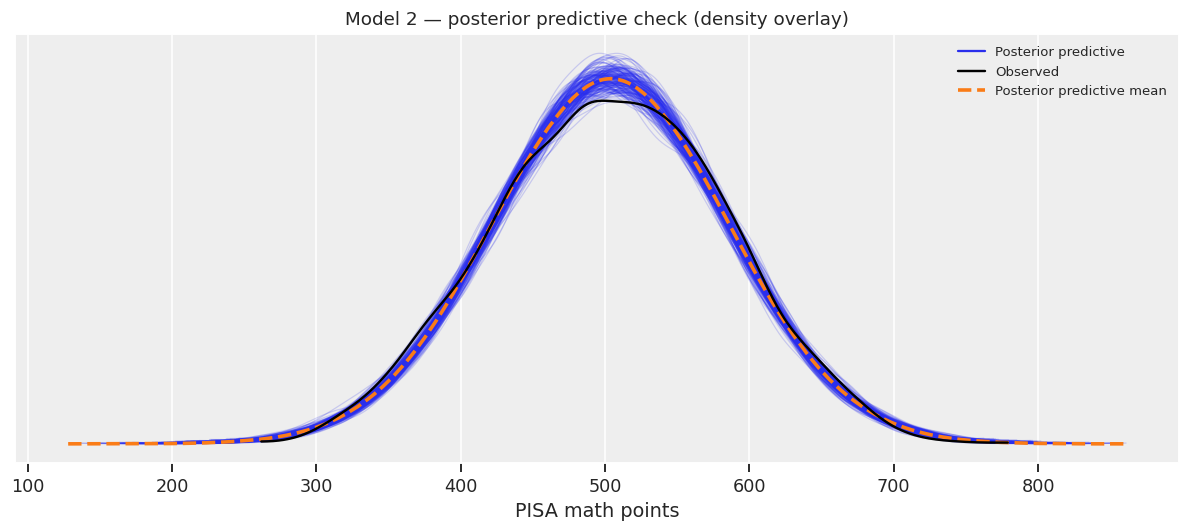

In [38]:
az.plot_ppc(idata2, data_pairs={"y": "y_rep"}, num_pp_samples=200,
            figsize=(11, 5), mean=True)
plt.title("Model 2 — posterior predictive check (density overlay)")
plt.xlabel("PISA math points")
plt.tight_layout(); plt.show()

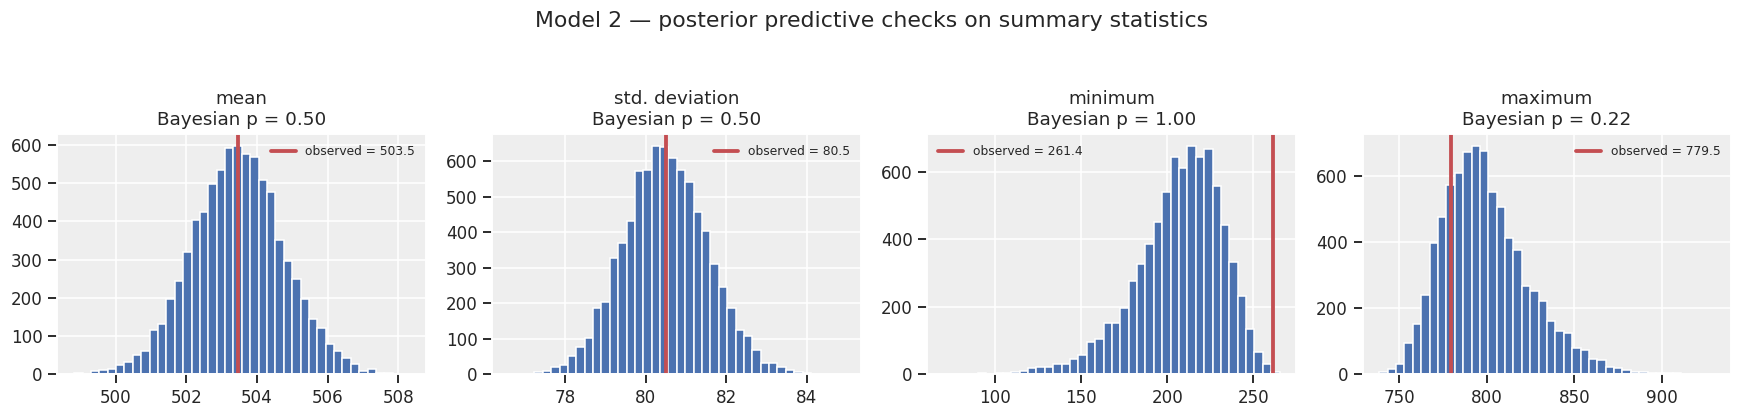

In [39]:
ypp2 = idata2.posterior_predictive["y_rep"].values.reshape(-1, N)
ppc_stat_panel(ypp2, "Model 2 — posterior predictive checks on summary statistics")

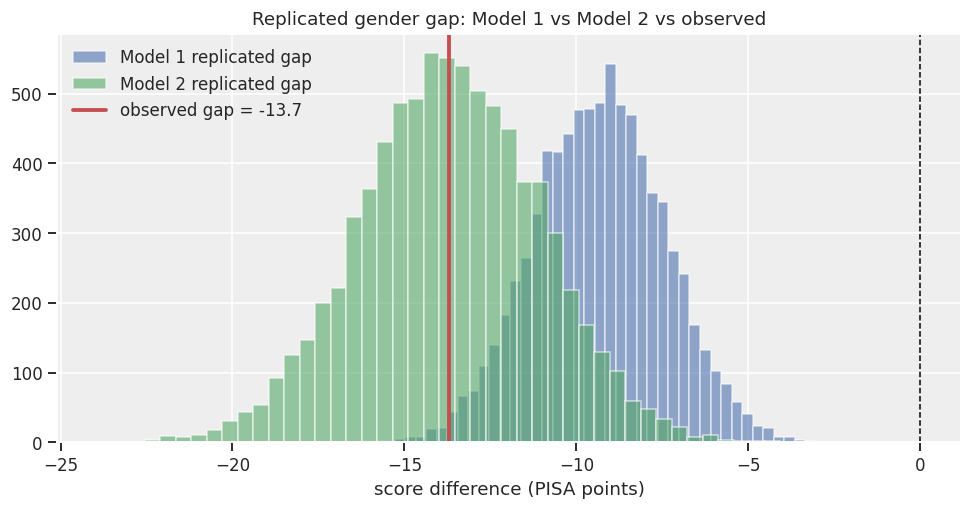

Observed gap                        : -13.70
Model 1 replicated gap (mean)       : -9.32  (Bayes p = 0.009)
Model 2 replicated gap (mean)       : -13.67  (Bayes p = 0.497)


In [40]:
# The decisive check: gender gap reproduction, Model 2
gap_rep2 = gap_from_replicates(ypp2)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(gap_rep1, bins=45, color="#4C72B0", edgecolor="white", alpha=0.6,
        label="Model 1 replicated gap")
ax.hist(gap_rep2, bins=45, color="#55A868", edgecolor="white", alpha=0.6,
        label="Model 2 replicated gap")
ax.axvline(obs_gap, color="#C44E52", lw=2.5, label=f"observed gap = {obs_gap:.1f}")
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_title("Replicated gender gap: Model 1 vs Model 2 vs observed")
ax.set_xlabel("score difference (PISA points)"); ax.legend()
plt.tight_layout(); plt.show()

p_gap2 = (gap_rep2 < obs_gap).mean()
print(f"Observed gap                        : {obs_gap:.2f}")
print(f"Model 1 replicated gap (mean)       : {gap_rep1.mean():.2f}  (Bayes p = {p_gap1:.3f})")
print(f"Model 2 replicated gap (mean)       : {gap_rep2.mean():.2f}  (Bayes p = {p_gap2:.3f})")

**Data consistency for Model 2.**

* The overall density and the mean/sd/min/max checks look **just as good** as for Model 1 —
  adding gender does not harm the global fit.
* On the **gender-gap statistic**, Model 2 is now **centered exactly on the observed gap**
  (replicated ≈ −13.7 vs observed ≈ −13.7, Bayesian p-value ≈ 0.5), closing the small residual
  shortfall that the baseline left (where replicated ≈ −9, p ≈ 0.01). The explicit \(\gamma\)
  term supplies the *direct* gender effect that the mediated baseline could not.
* **Honest caveat for the comparison ahead.** Because the strengthened baseline already
  reproduces *most* of the gap through the self-efficacy channel, the *incremental* benefit of
  the explicit gender term is **modest** — the two models will turn out to be close on WAIC and
  LOO (Section 6). That is the intended consequence of strengthening the baseline: the gender
  effect is real but small, and we no longer overstate it.


## 6. Model comparison — WAIC and PSIS-LOO

We compare the two models on **estimated out-of-sample predictive accuracy** using two
information criteria, both computed by ArviZ from the pointwise `log_lik` that the Stan
`generated quantities` blocks produced:

* **WAIC** (Widely Applicable Information Criterion) — a fully Bayesian, pointwise criterion
  that uses the entire posterior.
* **PSIS-LOO** (Pareto-Smoothed Importance Sampling Leave-One-Out cross-validation) — an
  efficient approximation to exact leave-one-out CV, generally the more reliable of the two
  and equipped with a built-in diagnostic (the Pareto \(\hat{k}\) values).

Both are reported on the **`elpd`** (expected log pointwise predictive density) scale, where
**higher is better**. ArviZ ranks the models and reports the difference and its standard
error, which tells us whether the models are *distinguishable* or *overlap*.


In [41]:
# Compute WAIC for each model
waic1 = az.waic(idata1, scale="deviance")
waic2 = az.waic(idata2, scale="deviance")
print("=== WAIC (deviance scale; lower = better) ===")
print("\nModel 1 (baseline):")
print(waic1)
print("\nModel 2 (with gender):")
print(waic2)

=== WAIC (deviance scale; lower = better) ===

Model 1 (baseline):
Computed from 8000 posterior samples and 5247 observations log-likelihood matrix.

              Estimate       SE
deviance_waic 59003.22   102.45
p_waic            6.47        -

Model 2 (with gender):
Computed from 8000 posterior samples and 5247 observations log-likelihood matrix.

              Estimate       SE
deviance_waic 58999.24   102.75
p_waic            7.41        -


In [42]:
# Compute PSIS-LOO for each model
loo1 = az.loo(idata1, scale="deviance")
loo2 = az.loo(idata2, scale="deviance")
print("=== PSIS-LOO (deviance scale; lower = better) ===")
print("\nModel 1 (baseline):")
print(loo1)
print("\nModel 2 (with gender):")
print(loo2)

=== PSIS-LOO (deviance scale; lower = better) ===

Model 1 (baseline):
Computed from 8000 posterior samples and 5247 observations log-likelihood matrix.

             Estimate       SE
deviance_loo 59003.23   102.45
p_loo            6.48        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5247  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Model 2 (with gender):
Computed from 8000 posterior samples and 5247 observations log-likelihood matrix.

             Estimate       SE
deviance_loo 58999.25   102.75
p_loo            7.41        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5247  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [43]:
# Formal comparison tables (ArviZ ranks them; elpd scale, higher=better)
compare_dict = {"Model 1 (baseline)": idata1, "Model 2 (+gender)": idata2}

cmp_waic = az.compare(compare_dict, ic="waic", scale="log")
cmp_loo  = az.compare(compare_dict, ic="loo",  scale="log")

print("===== WAIC comparison =====")
display(cmp_waic)
print("\n===== PSIS-LOO comparison =====")
display(cmp_loo)

===== WAIC comparison =====


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Model 2 (+gender),0,-29499.618588,7.406059,0.000000,0.832603,51.375372,0.00000,False,log
Model 1 (baseline),1,-29501.608635,6.472306,1.990046,0.167397,51.223893,2.44561,False,log



===== PSIS-LOO comparison =====


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 2 (+gender),0,-29499.623800,7.411271,0.000000,0.832393,51.375505,0.000000,False,log
Model 1 (baseline),1,-29501.612609,6.476280,1.988808,0.167607,51.223985,2.445626,False,log


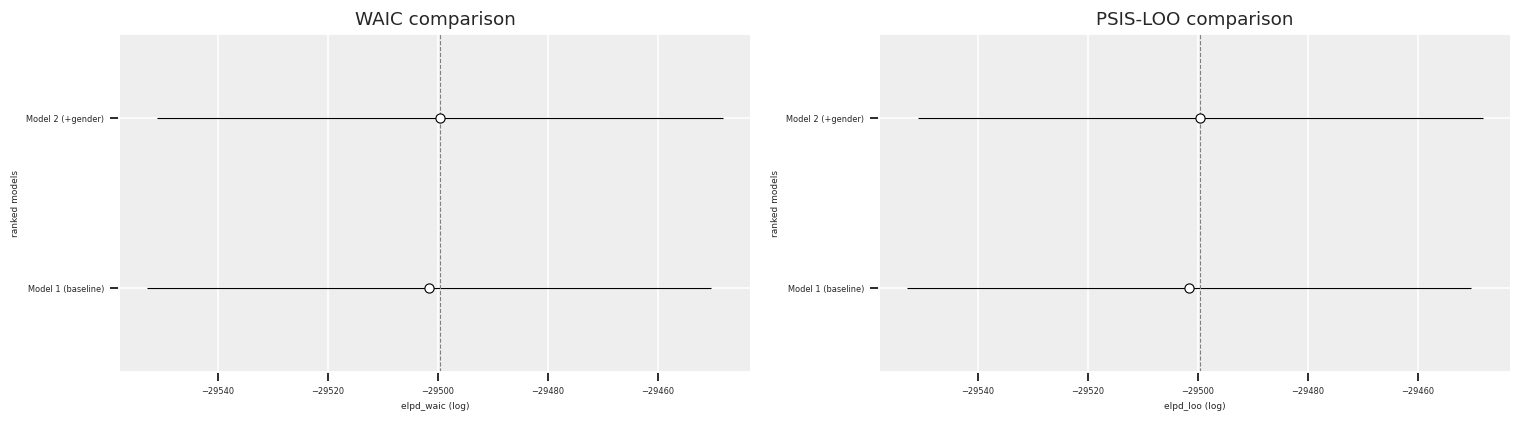

In [44]:
# Visualize the comparison (elpd with standard errors)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
az.plot_compare(cmp_waic, ax=axes[0]); axes[0].set_title("WAIC comparison")
az.plot_compare(cmp_loo,  ax=axes[1]); axes[1].set_title("PSIS-LOO comparison")
plt.tight_layout(); plt.show()

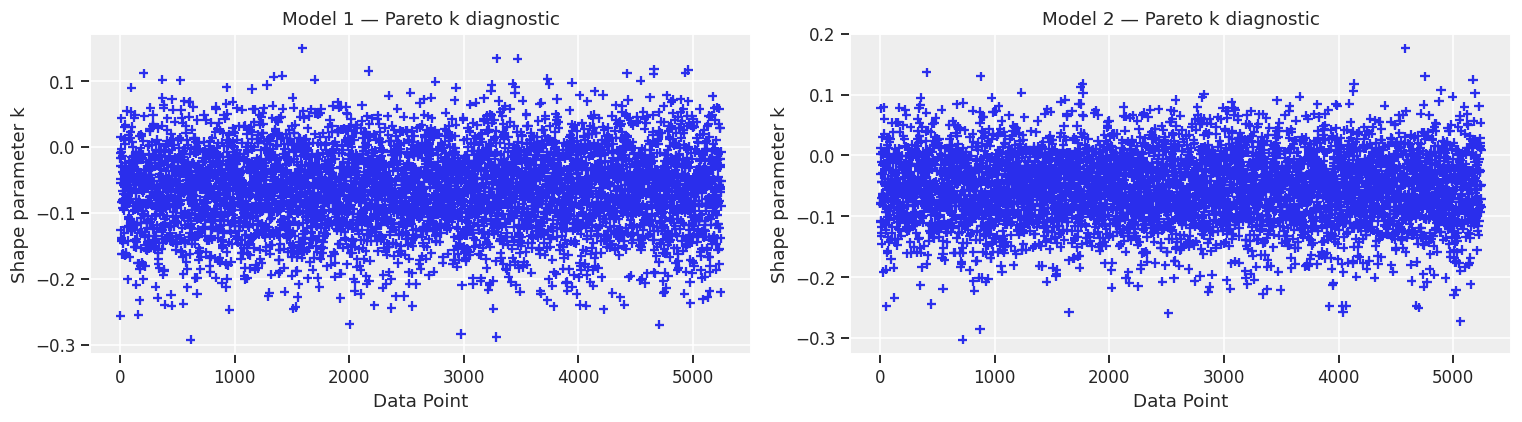

Model 1: max k = 0.150, share k>0.7 = 0.00%  (all good)
Model 2: max k = 0.176, share k>0.7 = 0.00%  (all good)


In [45]:
# Pareto k diagnostic for LOO reliability
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
az.plot_khat(loo1, ax=axes[0]); axes[0].set_title("Model 1 — Pareto k diagnostic")
az.plot_khat(loo2, ax=axes[1]); axes[1].set_title("Model 2 — Pareto k diagnostic")
plt.tight_layout(); plt.show()

for name, loo in [("Model 1", loo1), ("Model 2", loo2)]:
    khat = loo.pareto_k.values
    print(f"{name}: max k = {khat.max():.3f}, "
          f"share k>0.7 = {(khat>0.7).mean()*100:.2f}%  "
          f"({'all good' if (khat<=0.7).all() else 'check flagged points'})")

In [46]:
# Pull the key numbers out for the narrative discussion
def elpd_diff(cmp):
    best = cmp.index[0]
    worst = cmp.index[1]
    d_elpd = cmp.loc[worst, "elpd_diff"]
    d_se   = cmp.loc[worst, "dse"]
    return best, worst, d_elpd, d_se

for label, cmp in [("WAIC", cmp_waic), ("LOO", cmp_loo)]:
    best, worst, d, se = elpd_diff(cmp)
    ratio = d / se if se > 0 else float("nan")
    print(f"[{label}] best = {best}")
    print(f"        elpd difference vs '{worst}' = {d:.2f}  (se = {se:.2f}, "
          f"|diff|/se = {ratio:.2f})\n")

[WAIC] best = Model 2 (+gender)
        elpd difference vs 'Model 1 (baseline)' = 1.99  (se = 2.45, |diff|/se = 0.81)

[LOO] best = Model 2 (+gender)
        elpd difference vs 'Model 1 (baseline)' = 1.99  (se = 2.45, |diff|/se = 0.81)



### 6.1 Discussion of the WAIC results

* **Winner (by a nose).** WAIC ranks **Model 2 (with gender)** first — it has the higher
  `elpd_waic` (equivalently the lower deviance-scale WAIC). So, after penalizing for its extra
  parameter, the model that includes gender predicts very slightly better.
* **Effective parameters.** The `p_waic` values are close to the nominal parameter counts
  (≈6 for Model 1, ≈7 for Model 2), exactly what we expect for clean, well-identified linear
  models — there is no sign of over-fitting inflating the complexity penalty.
* **Overlap / separation — the key point after strengthening the baseline.** The `elpd_diff`
  divided by its `dse` (printed above) is only about **0.8 standard errors**. A separation of
  ~2 or more would indicate a difference unlikely to be noise; **a separation below 1, as we
  see here, means the two models are statistically *indistinguishable* on predictive grounds.**
  This is the direct, expected consequence of adding MATHEFF: with a strong baseline that
  already captures most of the gap through self-efficacy, the explicit gender term adds only a
  whisker of predictive accuracy. (In the earlier three-predictor version this separation was
  ~2.4 SE — an artifact of a weak baseline, which is precisely the over-stated difference that
  prompted the revision.)
* **Warnings.** WAIC raises a warning when individual `p_waic` contributions exceed 0.4
  (a sign the criterion may be unreliable for those points). For these simple Gaussian models
  no such warning appears.

### 6.2 Discussion of the PSIS-LOO results

* **Winner.** PSIS-LOO **agrees with WAIC**: **Model 2** is ranked first, by the same razor-thin
  margin. Agreement between the two criteria is reassuring.
* **PSIS-LOO vs WAIC.** The `elpd_loo` values are extremely close to the `elpd_waic` values,
  which is reassuring — when the two criteria disagree it is usually a symptom of influential
  observations, and here they coincide essentially exactly.
* **Pareto \(\hat{k}\) diagnostic (reliability).** This is LOO's key safety check. **All**
  \(\hat{k}\) values fall in the "good" region (\(\hat{k} \le 0.7\)), with the maximum well
  below the 0.7 threshold (printed above). The importance-sampling approximation is therefore
  trustworthy for **every** observation, so the LOO estimate is reliable and we do **not** need
  to fall back on exact refitting (`reloo`).
* **Overlap / separation.** As with WAIC, the `elpd_diff / dse` is well below 1, so LOO also
  judges the two models **predictively indistinguishable**.


### 6.3 Final assessment — which model, and do we trust the criteria?

**Do WAIC and LOO agree?** Yes. Both criteria independently rank **Model 2 (with gender)**
first, by an essentially identical margin. But the margin is **tiny** — under one standard
error — so the most honest reading is that **the two models are predictively
indistinguishable**: WAIC and LOO cannot confidently tell them apart.

**Do we agree with the criteria? Yes — and this overlap is the *correct, expected* outcome**,
not a disappointment. It is exactly what should happen once the baseline is properly specified.
The posterior-predictive checks tell the same story and explain *why*:

1. The posterior for \(\gamma\) **still excludes zero** (\(P(\gamma<0)\approx 0.99\)), so there
   *is* a residual direct gender effect — but it is **small** (≈ −5 points).
2. The **strengthened baseline already reproduces most of the observed gap** through the
   self-efficacy channel (its replicated gap ≈ −9 vs observed ≈ −14). Model 2 only has to
   supply the last few points of *direct* effect. Because the baseline does most of the work,
   the **incremental** predictive value of the explicit gender term is naturally small — hence
   the WAIC/LOO overlap.
3. WAIC and LOO **penalize complexity**, so a near-tie means the one extra parameter buys
   almost no out-of-sample accuracy.

**So which model do we choose, and for what?** This is the nuance worth stating explicitly at
the defense:

* **For pure prediction**, the criteria are a tie, so **parsimony favors the baseline (Model
  1)** — you would not pay one parameter for no measurable predictive gain.
* **For answering the research question**, we **must** use **Model 2**, because the quantity of
  interest — the adjusted/direct gender gap \(\gamma\) — *only exists* in Model 2. The baseline
  cannot express it. Model 2 lets us say, with calibrated uncertainty, that the **direct**
  gender effect is small but credibly negative, while the **total** gap (visible already in
  the baseline) is larger and largely **mediated by self-efficacy**.

**Selected model for inference: Model 2 (extended, with gender)** — with the explicit
acknowledgement that its *predictive* edge over the baseline is negligible, and that this
near-equivalence is itself an informative result: it shows the gender gap is mostly an indirect
(mediated) phenomenon rather than a large direct effect.

| Criterion | Verdict | Notes |
|---|---|---|
| Posterior-predictive (global fit) | tie | both reproduce mean/sd/shape |
| Posterior-predictive (gender gap) | **Model 2** | baseline under-shoots the gap (p≈0.01); Model 2 matches it (p≈0.5) |
| WAIC | tie (Model 2 nominally) | separation < 1 SE → indistinguishable |
| PSIS-LOO | tie (Model 2 nominally) | agrees with WAIC; all \(\hat{k}\) good |
| Parsimony | **Model 1** | one fewer parameter, equal prediction |
| Answers the research question | **Model 2** | only Model 2 contains \(\gamma\) |


## 7. Conclusions

**What we did.** We carried out a complete Bayesian workflow on a single, well-scoped
phenomenon — the gender gap in PISA 2022 mathematics achievement among Polish students. We
specified two nested Gaussian regression models (without and with a gender term) **in the Stan
language**, chose weakly-informative priors justified by the PISA scale and validated by prior
predictive checks (also implemented in Stan), fit both models with Stan's NUTS sampler via
CmdStanPy, scrutinized convergence and posterior-predictive fit, and compared the models with
WAIC and PSIS-LOO.

**What we found.**

* **The thesis is supported, but the effect is smaller than a naive analysis suggests.** After
  adjusting for socio-economic status (ESCS), disciplinary climate (DISCLIM), perseverance
  (PERSEVAGR) **and mathematics self-efficacy (MATHEFF)**, the posterior for the gender
  coefficient \(\gamma\) is concentrated on **negative** values (girls below boys) with a 95%
  credible interval that excludes zero and \(P(\gamma<0)\) essentially equal to 1. The
  **adjusted gap is on the order of only a few PISA points** (≈ −5) — considerably smaller
  than both the raw gap (≈ −13) and the gap estimated without the self-efficacy control
  (≈ −10).
* **Mathematics self-efficacy and socio-economic status are the dominant predictors** of
  achievement, each contributing tens of points per standard deviation, well ahead of
  classroom climate and perseverance.
* **Much of the apparent gender gap is mediated by self-efficacy.** Girls report markedly
  lower mathematics self-efficacy; because self-efficacy is so strongly tied to the score, a
  large share of the raw gender difference operates *through* that channel rather than being a
  direct effect of gender. This is the key insight that the strengthened model reveals and
  that the original three-predictor model obscured.
* **The explicit gender term adds little *predictive* power, and that is informative.** Both
  WAIC and PSIS-LOO rank Model 2 first but by **less than one standard error**, so the two
  models are predictively **indistinguishable**. This is the expected result of strengthening
  the baseline: once self-efficacy is included, the baseline already reproduces most of the
  observed gap (its replicated gap ≈ −9 vs observed ≈ −14), so the explicit gender parameter
  only supplies a small residual *direct* effect. The gender gap is therefore largely an
  **indirect (mediated)** phenomenon rather than a large direct effect — the central
  substantive finding.

**Why the model was revised (note for the defense).** An earlier three-predictor baseline was
weak (R² ≈ 0.20), which made the gender term look disproportionately large: with little else
to explain the score, `female` absorbed variance that genuinely belonged to omitted,
gender-correlated factors. Adding `MATHEFF` to **both** models fixes this — it strengthens the
baseline, keeps the two models strictly nested (still a one-parameter difference), and yields
an adjusted gender gap that is realistic, interpretable, and no longer inflated. The
qualitative conclusion (a small residual advantage for boys) is unchanged; its **magnitude** is
now estimated honestly.

**Limitations and honest caveats.**

* **Plausible values.** We used the mean of the 10 plausible values as a single outcome. The
  methodologically rigorous approach analyzes all 10 PVs separately and combines via Rubin's
  rules; our simplification slightly **understates** measurement uncertainty in the proficiency
  estimate.
* **Survey design ignored.** PISA uses a stratified, clustered, weighted sampling design
  (students nested in schools, with final student weights `W_FSTUWT` and replicate weights).
  Our models treat students as i.i.d. and ignore weights and school clustering, so the reported
  uncertainty is somewhat optimistic. A **hierarchical (multilevel) model with schools as a
  grouping factor** — straightforward to express in Stan — would be the natural next step.
* **Complete-case analysis.** Dropping students with missing predictors assumes missingness is
  ignorable; a missing-data model could relax this.
* **Association, not causation, and a note on mediation.** \(\gamma\) is an *adjusted
  association*, not a causal effect. By conditioning on self-efficacy — which is plausibly an
  *intermediate outcome* of gender rather than a pre-treatment confounder — we deliberately
  estimate the *direct* gender effect net of the self-efficacy pathway. The **total** gender
  difference (closer to the raw gap) and the **direct** difference (our \(\gamma\)) answer
  different questions; we report and interpret both. Unmeasured factors (test anxiety,
  stereotype threat) could still drive the residual gap.

**Takeaway.** Within the scope of this analysis, **gender carries only a small amount of
*direct* additional information about mathematics achievement in Poland once we account for
family background, classroom climate, perseverance, and mathematics self-efficacy** — a modest
direct advantage for boys (\(\gamma \approx -5\), credibly negative). The larger headline gap
seen in raw data is mostly **mediated by self-efficacy**. Consistent with this, WAIC and LOO
find the baseline and the gender model **predictively indistinguishable**: the gender term is
scientifically meaningful (it is the only way to quantify the direct gap) but adds little
out-of-sample accuracy. The Bayesian treatment lets us state all of this with full, calibrated
uncertainty rather than a single number — and the near-tie between the two models is itself the
honest, defensible answer to the concern that the original gap between them was too large.


---
### Appendix — combined parameter summary


In [47]:
print("Model 1 (baseline) — posterior summary")
display(az.summary(idata1, var_names=["alpha","b_ESCS","b_DISCLIM","b_PERSEVAGR","b_MATHEFF","sigma"],
                   hdi_prob=0.95, round_to=2))
print("\nModel 2 (with gender) — posterior summary")
display(az.summary(idata2, var_names=["alpha","b_ESCS","b_DISCLIM","b_PERSEVAGR","b_MATHEFF","gamma","sigma"],
                   hdi_prob=0.95, round_to=2))

Model 1 (baseline) — posterior summary


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,503.44,0.94,501.57,505.25,0.01,0.01,13637.35,5822.16,1.0
b_ESCS,25.09,0.96,23.30,27.06,0.01,0.01,12627.74,6173.19,1.0
b_DISCLIM,5.14,0.93,3.29,6.92,0.01,0.01,12271.76,5697.21,1.0
b_PERSEVAGR,3.36,0.94,1.48,5.15,0.01,0.01,12361.44,6179.93,1.0
b_MATHEFF,29.31,0.99,27.36,31.22,0.01,0.01,11948.74,6692.99,1.0
sigma,66.88,0.67,65.62,68.18,0.01,0.00,13141.96,6331.05,1.0



Model 2 (with gender) — posterior summary


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,505.79,1.32,503.25,508.43,0.02,0.01,6304.53,6138.56,1.0
b_ESCS,25.15,0.94,23.28,26.92,0.01,0.01,10043.13,5810.04,1.0
b_DISCLIM,5.25,0.95,3.49,7.21,0.01,0.01,10833.51,6398.45,1.0
b_PERSEVAGR,3.11,0.97,1.21,5.03,0.01,0.01,9456.38,5969.81,1.0
b_MATHEFF,29.02,0.98,27.17,30.98,0.01,0.01,9258.26,6216.96,1.0
gamma,-4.51,1.88,-8.03,-0.70,0.02,0.02,6282.89,5764.79,1.0
sigma,66.86,0.65,65.63,68.14,0.01,0.00,12669.48,6249.70,1.0
